<a href="https://colab.research.google.com/github/icosrle31/Test_ENNOH/blob/main/Dual_H2_Electricity_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install pypsa highspy openpyxl "xarray<=2024.9.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.3/358.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 186.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 186.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import json
import time
import pypsa
import warnings

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model")


In [4]:
sys.path.append(PROJECT_DIR)

from modules.getting_input_data import get_input_data

input_file_name = "data/input_file.xlsx"
input_data = get_input_data(PROJECT_DIR, input_file_name)

File found at: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/input_file.xlsx
The input data has been imported.


In [5]:
project_name = input_data["project_name"]
zones = json.loads(input_data["zones"])
year = input_data["year"]
scenario =  input_data["scenario"]

INTER_DIR = os.path.join(PROJECT_DIR, input_data["subfolder"])

capacities = {}

In [6]:
input_data

{'project_name': 'Italy',
 'zones': '["AT00","ITSI","ITSA","ITCA","ITS1","ITCS","ITCN","ITN1","SI00"]',
 'year': 2040,
 'scenario': 'GA',
 'weather_year': 2010,
 'subfolder': 'intermediate_data',
 'data_dir': 'data',
 'FLEX': True,
 'NTC': True,
 'H2': True,
 'Synthetic_fuels': False,
 'share': 0.5,
 'prefix': '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model',
 'input_data_path': '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/input_file.xlsx'}

In [7]:
zones

['AT00', 'ITSI', 'ITSA', 'ITCA', 'ITS1', 'ITCS', 'ITCN', 'ITN1', 'SI00']

# Reading Itermediate_data Folder

Most data is imported from the intermediate_data folder, specifically:
*   Generation capacities
*   RES profiles
*   Hydrogen data
*   Demand profiles

The only exception is NTC data - electricity and hydrogen, which is sourced directly from the raw data folder.

### Capacities

In [8]:
# Define the path to the capacities file
capacities_file_path = os.path.join(INTER_DIR, project_name, f"capacity_{year}.json")

# Load the capacities data
try:
    with open(capacities_file_path, 'r') as f:
        capacities = json.load(f)
    print(f"✅ Successfully loaded capacities for {project_name} project in {year}.")
    zones = list(capacities.keys())
    print(f"    Zones are:", zones)
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(capacities_file_path)} was not found. Please ensure it's in the correct directory ({os.path.join(PROJECT_DIR, project_name)}).")
    # Diagnostic: List files in the project directory to help the user
    print(f"Files in {os.path.join(PROJECT_DIR, project_name)}:")
    try:
        for item in os.listdir(os.path.join(PROJECT_DIR, project_name)):
            print(f"  - {item}")
    except Exception as e:
        print(f"  Could not list directory contents: {e}")
except json.JSONDecodeError:
    print(f"❌ Error: Could not decode JSON from {os.path.basename(capacities_file_path)}. Check file format.")
except Exception as e:
    print(f"❌ An unexpected error occurred while loading capacities: {e}")

✅ Successfully loaded capacities for Italy project in 2040.
    Zones are: ['AT00', 'ITSI', 'ITSA', 'ITCA', 'ITS1', 'ITCS', 'ITCN', 'ITN1', 'SI00']


### Electricity

#### RES Profiles

In [9]:
# Define the path to the RES profiles file
res_profiles_path = os.path.join(INTER_DIR, project_name, f"RES_profiles_{year}.csv")

# Load the data and parse datetime in column 0
try:
    RES_profiles = pd.read_csv(res_profiles_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully loaded RES profiles. Shape: {RES_profiles.shape}")
    display(RES_profiles.head(3))
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(res_profiles_path)} was not found.\nCheck if it exists in {os.path.dirname(res_profiles_path)}.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded RES profiles. Shape: (8784, 109)


,AT00_Utility_PV,AT00_Rooftop_PV,ITSI_Utility_PV,ITSI_Rooftop_PV,ITSA_Utility_PV,ITSA_Rooftop_PV,ITCA_Utility_PV,ITCA_Rooftop_PV,ITS1_Utility_PV,ITS1_Rooftop_PV,...,ITCS_PS_Closed_Max_MW,ITCN_PS_Open_Inflow_MW,ITCN_PS_Closed_Inflow_MW,ITN1_PS_Open_Inflow_MW,ITN1_PS_Open_Max_MW,ITN1_PS_Closed_Inflow_MW,ITN1_PS_Closed_Max_MW,SI00_PS_Open_Inflow_MW,SI00_PS_Closed_Inflow_MW,SI00_PS_Closed_Max_MW
2040-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1000,0.0,0.0,1235.485678,2774.858,0.0,2430.2,0.0,0.0,600
2040-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1000,0.0,0.0,1235.485678,2774.858,0.0,2430.2,0.0,0.0,600
2040-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1000,0.0,0.0,1235.485678,2774.858,0.0,2430.2,0.0,0.0,600


In [10]:
# Profiles data presentation
for z in zones:
    zone_specific_cols = [col for col in RES_profiles.columns if col.startswith(f"{z}_")]
    print(f"Profiles for zone {z}:", zone_specific_cols)

Profiles for zone AT00: ['AT00_Utility_PV', 'AT00_Rooftop_PV', 'AT00_Wind_Onshore', 'AT00_Wind_Offshore', 'AT00_RoR_MW', 'AT00_Pondage_MW', 'AT00_Res_Inflow_MW', 'AT00_Res_Min_Turbine_MW', 'AT00_Res_Max_Turbine_MW', 'AT00_PS_Open_Inflow_MW', 'AT00_PS_Open_Max_MW', 'AT00_PS_Closed_Inflow_MW', 'AT00_PS_Closed_Max_MW']
Profiles for zone ITSI: ['ITSI_Utility_PV', 'ITSI_Rooftop_PV', 'ITSI_Wind_Onshore', 'ITSI_Wind_Offshore', 'ITSI_RoR_MW', 'ITSI_Pondage_MW', 'ITSI_Res_Inflow_MW', 'ITSI_Res_Min_Turbine_MW', 'ITSI_Res_Max_Turbine_MW', 'ITSI_PS_Open_Inflow_MW', 'ITSI_PS_Open_Max_MW', 'ITSI_PS_Closed_Inflow_MW', 'ITSI_PS_Closed_Max_MW']
Profiles for zone ITSA: ['ITSA_Utility_PV', 'ITSA_Rooftop_PV', 'ITSA_Wind_Onshore', 'ITSA_Wind_Offshore', 'ITSA_RoR_MW', 'ITSA_Pondage_MW', 'ITSA_Res_Inflow_MW', 'ITSA_Res_Min_Turbine_MW', 'ITSA_Res_Max_Turbine_MW', 'ITSA_PS_Open_Inflow_MW', 'ITSA_PS_Closed_Inflow_MW', 'ITSA_PS_Closed_Max_MW']
Profiles for zone ITCA: ['ITCA_Utility_PV', 'ITCA_Rooftop_PV', 'ITCA_

In [11]:
# Reload capacities to restore the popped values
with open(capacities_file_path, 'r') as f:
    capacities = json.load(f)

def extract_first_number(v):
    if isinstance(v, dict):
        return extract_first_number(next(iter(v.values()))) if v else 0.0
    elif isinstance(v, (list, tuple)):
        return extract_first_number(v[0]) if v else 0.0
    else:
        try:
            return float(v)
        except (ValueError, TypeError):
            return 0.0

# Iterate through the zones and transfer the 'Other RES' data
for z in list(capacities.keys()):
    if 'Other RES' in capacities[z]:
        val = capacities[z].pop('Other RES')
        num_val = extract_first_number(val)
        # Broadcast the scalar value to all rows in the dataframe
        RES_profiles[f"{z}_Other_RES"] = num_val

print("✅ Successfully transferred 'Other RES' capacities to RES profiles.")

✅ Successfully transferred 'Other RES' capacities to RES profiles.


#### Net Transfer Capacity

NTC data is imported directly from raw data - Line data, with two sheets, referenceGrid_Electrcity and referenceGrid_Hydrogen

In [12]:
import pandas as pd
import os

# Path to the specific line data file
elec_line_path = os.path.join(PROJECT_DIR, "data", "Line data", "ReferenceGrid_Electricity.xlsx")

try:
    # Read the specific sheet '2030'
    ntc_raw_df = pd.read_excel(elec_line_path, sheet_name='2030')
    print(f"✅ Successfully loaded ReferenceGrid_Electricity. Columns found: {ntc_raw_df.columns.tolist()}")

    ntc_prepared = []

    for _, row in ntc_raw_df.iterrows():
        if '-' in str(row['Border']):
            z1, z2 = str(row['Border']).split('-')

            if z1 in zones and z2 in zones:
                # Use a default loss if 'Losses' column is missing or named differently
                loss_val = row.get('Losses', 0.95)
                if isinstance(loss_val, str):
                    loss_val = float(loss_val.replace(',', '.'))

                # Direction 1: z1 -> z2
                ntc_prepared.append({
                    'zone 1': z1,
                    'zone 2': z2,
                    'capacity, MW': float(row['Summary Direction 1']),
                    'losses': loss_val
                })

                # Direction 2: z2 -> z1
                ntc_prepared.append({
                    'zone 1': z2,
                    'zone 2': z1,
                    'capacity, MW': float(row['Summary Direction 2']),
                    'losses': loss_val
                })

    NTC_elec_df = pd.DataFrame(ntc_prepared)
    if not NTC_elec_df.empty:
        # FIX: Create a separate list variable instead of overwriting the DataFrame
        NTC_elec_list = list(zip(NTC_elec_df['zone 1'], NTC_elec_df['zone 2']))
        print(f"Found {len(NTC_elec_df)} directed connections.")
        display(NTC_elec_df.head(3))
    else:
        print("☐ No matching connections found for the current project zones.")

except Exception as e:
    print(f"❌ An error occurred: {e}")
    # Fallback diagnostic to see the actual dataframe structure
    if 'ntc_raw_df' in locals():
        display(ntc_raw_df.head(3))

✅ Successfully loaded ReferenceGrid_Electricity. Columns found: ['Border', 'Summary Direction 1', 'Summary Direction 2']
Found 20 directed connections.


,zone 1,zone 2,"capacity, MW",losses
0,AT00,ITN1,875.0,0.95
1,ITN1,AT00,695.0,0.95
2,AT00,SI00,950.0,0.95


In [13]:
# Filter NTC_elec_df for zones belonging to the project
# and create the NTC_elec_list

# Note: NTC_elec_df is the DataFrame, and NTC_elec_list is the zipped list.
if 'NTC_elec_df' in locals() and isinstance(NTC_elec_df, pd.DataFrame):
    NTC_elec_list = list(zip(NTC_elec_df['zone 1'], NTC_elec_df['zone 2']))
    print(f"Found {len(NTC_elec_df)} directed connections.")
    print("\nConnections List (Zone Pairs):")
    print(NTC_elec_list)
else:
    print("❌ NTC_elec_df is not available as a DataFrame. Please re-run cell 5d8ea69d.")

Found 20 directed connections.

Connections List (Zone Pairs):
[('AT00', 'ITN1'), ('ITN1', 'AT00'), ('AT00', 'SI00'), ('SI00', 'AT00'), ('ITCN', 'ITCS'), ('ITCS', 'ITCN'), ('ITCN', 'ITN1'), ('ITN1', 'ITCN'), ('ITCS', 'ITS1'), ('ITS1', 'ITCS'), ('ITCS', 'ITSA'), ('ITSA', 'ITCS'), ('ITN1', 'SI00'), ('SI00', 'ITN1'), ('ITS1', 'ITCA'), ('ITCA', 'ITS1'), ('ITSI', 'ITCA'), ('ITCA', 'ITSI'), ('ITCS', 'ITN1'), ('ITN1', 'ITCS')]



### Hydrogen Data



In [14]:
import os
import json

# Define the path to the combined H2 data file
h2_data_path = os.path.join(INTER_DIR, project_name, f"H2_data_{scenario}_{year}.json")

# Load the H2 data
try:
    with open(h2_data_path, 'r') as f:
        h2_data = json.load(f)
    print(f"✅ Successfully loaded H2 data from: {os.path.basename(h2_data_path)}")
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(h2_data_path)} was not found in {os.path.dirname(h2_data_path)}.")
except json.JSONDecodeError:
    print(f"❌ Error: Could not decode JSON from {os.path.basename(h2_data_path)}. Check file format.")
except Exception as e:
    print(f"❌ An unexpected error occurred while loading H2 data: {e}")


✅ Successfully loaded H2 data from: H2_data_GA_2040.json


#### SMR capacity and H2 Storage

In [15]:
# Extract SMR capacity data from the combined h2_data dictionary
try:
    if 'SMR_data' in h2_data:
        smr_capacities = pd.DataFrame(h2_data['SMR_data'])
        # Assuming 'NODE' is the first column, set it as the index to match index_col=0
        if 'NODE' in smr_capacities.columns:
            smr_capacities.set_index('NODE', inplace=True)

        print("✅ Successfully extracted SMR capacity data from combined H2 data.")
        display(smr_capacities.head())
    else:
        print("❌ Error: 'SMR_data' key not found in h2_data.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully extracted SMR capacity data from combined H2 data.


,YEAR,SCENARIO,CAPACITY [MW],HEAT RATE [GJ/MWh],VO&M CHARGE [€/MWh],MUST-RUN UNITS,CCS
NODE,,,,,,,
AT,2040,Global Ambition,423.35,4.74,3.38,0,False
IT,2040,Global Ambition,2684.98,5.18,4.47,0,True
SI,2040,Global Ambition,0.00,0.00,0.00,0,False


In [16]:
# Extract H2 storage data from the combined h2_data dictionary
try:
    if 'Storage_data' in h2_data:
        h2_storage = pd.DataFrame(h2_data['Storage_data'])

        print("✅ Successfully extracted H2 storage data from combined H2 data.")
        display(h2_storage.head())
    else:
        print("❌ Error: 'Storage_data' key not found in h2_data.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully extracted H2 storage data from combined H2 data.


,NODE,YEAR,SCENARIO,H2 ZONE,CAPACITY [GWh],MAX POWER [MW],MAX LOAD [MW],MAX CAPACITY [GWh],MAX POWER EXPANSION [MW],MAX LOAD EXPANSION [MW],CHARGE EFFICIENCY [%],DISCHARGE EFFICIENCY [%]
0,AT,2040,All,ZONE 2,0.000000,0.00000,0.000000,5235.492341,1388.440833,1388.440833,99,100
1,IT,2040,All,ZONE 2,5180.000000,2005.01425,3204.038625,5180.000000,2005.014250,3204.038625,99,100
2,SI,2040,All,ZONE 2,0.000000,0.00000,0.000000,388.063711,283.602125,276.881708,99,100
3,AT,2040,Global Ambition,ZONE 1,8.630246,359.59360,359.593600,NaN,NaN,NaN,99,100
4,IT,2040,Global Ambition,ZONE 1,35.329840,1472.07600,1472.076000,NaN,NaN,NaN,99,100


In [17]:
# Extract H2 import data from the combined h2_data dictionary
try:
    if 'Import_data' in h2_data:
        h2_imports = pd.DataFrame(h2_data['Import_data'])

        # Set NODE as index if it exists to match previous logic
        if 'NODE' in h2_imports.columns:
            h2_imports.set_index('NODE', inplace=True)

        print(f"✅ Successfully extracted H2 import data from combined H2 data.")
        display(h2_imports.head())

        # Add H2 import capacities to model_data
        for zone in zones:
            country_code = zone[:2]
            if country_code in h2_imports.index:
                # Get the capacity, safely handling potential duplicate rows/series
                import_cap = h2_imports.loc[country_code, 'CAPACITY [MW]']
                if isinstance(import_cap, pd.Series):
                    import_cap = import_cap.sum()

                model_data[zone]['H2_import_capacity'] = import_cap

        print(f"✅ Successfully mapped H2 import capacities to {len(zones)} zones.")
    else:
        print("❌ Error: 'Import_data' key not found in h2_data.")

except Exception as e:
    print(f"❌ An unexpected error occurred while extracting H2 imports: {e}")

✅ Successfully extracted H2 import data from combined H2 data.


,YEAR,SCENARIO,CORRIDOR,NODE FROM,NODE TO,MAX CAPACITY [MW],OFFER QUANTITY [MW],OFFER PRICE [€/MWh],MAX ENERGY YEAR [GWh],Type,Fuel
0,2040,Global Ambition,DZ-IT-LOW,DZ,IT,14783.105023,14783.105023,26.775,129500.0,Pipeline,Pure Hydrogen
1,2040,Global Ambition,DZ-IT-HIGH,DZ,IT,14783.105023,14783.105023,44.625,129500.0,Pipeline,Pure Hydrogen


✅ Successfully mapped H2 import capacities to 9 zones.


#### NTC Hydrogen

In [18]:
import pandas as pd
import os

# Path to the specific hydrogen line data file
h2_line_path = os.path.join(PROJECT_DIR, "data", "Line data", "ReferenceGrid_Hydrogen.xlsx")

try:
    # Read the specific sheet '2030'
    ntc_h2_raw_df = pd.read_excel(h2_line_path, sheet_name='2030')
    print(f"✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: {ntc_h2_raw_df.columns.tolist()}")

    # Display the first few rows to verify structure
    display(ntc_h2_raw_df.head())

except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(h2_line_path)} was not found in {os.path.dirname(h2_line_data_path)}.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: ['Border', 'Summary Direction 1', 'Summary Direction 2']


,Border,Summary Direction 1,Summary Direction 2
0,AT-DE,6.25,6.25
1,AT-IBIT,5.25,7.00
2,AT-SI,0.00,0.00
3,AT-SK,6.00,6.00
4,BE-DE,3.79,3.79


In [19]:
NTC_h2_prepared = []

# Mapping for hydrogen-specific naming conventions
h2_zone_map = {
    'AT': 'AT00',
    'SI': 'SI00',
    'IBIT': 'ITN1'
}

try:
    for _, row in ntc_h2_raw_df.iterrows():
        border = str(row['Border'])
        if '-' in border:
            parts = border.split('-')
            z1_raw, z2_raw = parts[0].strip(), parts[1].strip()
            z1 = h2_zone_map.get(z1_raw, z1_raw)
            z2 = h2_zone_map.get(z2_raw, z2_raw)

            if z1 in zones and z2 in zones:
                cap1 = float(row['Summary Direction 1']) * 1e3
                cap2 = float(row['Summary Direction 2']) * 1e3

                if cap1 > 0 or cap2 > 0:
                    NTC_h2_prepared.append({
                        'zone 1': z1,
                        'zone 2': z2,
                        'capacity_MW': cap1,
                        'capacity_rev_MW': cap2,
                        'efficiency': 0.98
                    })

    NTC_H2_df = pd.DataFrame(NTC_h2_prepared)

    if not NTC_H2_df.empty:
        print(f"✅ Prepared {len(NTC_H2_df)} hydrogen interconnections.")
        display(NTC_H2_df)
    else:
        print("ℹ️ No matching hydrogen connections found for current project zones.")

except Exception as e:
    print(f"❌ Error processing H2 grid data: {e}")

✅ Prepared 1 hydrogen interconnections.


,zone 1,zone 2,capacity_MW,capacity_rev_MW,efficiency
0,AT00,ITN1,5250.0,7000.0,0.98


#### Import H2

In [20]:

# Extracting data from h2_imports
# We take the capacity from the first row (LOW) and the price
h2_import_capacity = h2_imports.iloc[0]['OFFER QUANTITY [MW]']
h2_import_price = h2_imports.iloc[0]['OFFER PRICE [€/MWh]']

# Generate the new dataframe for H2_import
H2_import_df = pd.DataFrame({
    'zone': ['ITSI'],
    'capacity': [h2_import_capacity],
    'price': [h2_import_price]
})

print("✅ Generated H2_import DataFrame for ITSI")
display(H2_import_df)

✅ Generated H2_import DataFrame for ITSI


,zone,capacity,price
0,ITSI,14783.105023,26.775


In [21]:
H2_import_df['capacity'] = 1.5 * H2_import_df['capacity']

### Demand Profiles

In [22]:
# Define the path to the demand profiles file
demand_profiles_path = os.path.join(INTER_DIR,project_name, f"demand_profiles_{scenario}_{year}.csv")

# Load the data and parse datetime in column 0
try:
    demand_profiles = pd.read_csv(demand_profiles_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully loaded demand profiles. Shape: {demand_profiles.shape}")
    display(demand_profiles.head(3))
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(demand_profiles_path)} was not found.\nCheck if it exists in {os.path.dirname(demand_profiles_path)}.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded demand profiles. Shape: (8784, 81)


,AT00_H2_zone_1,AT00_H2_zone_2,AT00_H2_heat,AT00_CH4_heat,AT00_El_market,AT00_El_prosumer,AT00_SNG,AT00_eDiesel,AT00_eKerosine,ITSI_H2_zone_1,...,ITN1_eKerosine,SI00_H2_zone_1,SI00_H2_zone_2,SI00_H2_heat,SI00_CH4_heat,SI00_El_market,SI00_El_prosumer,SI00_SNG,SI00_eDiesel,SI00_eKerosine
2040-01-01 00:00:00,1238.505084,4701.660764,2612.082863,0.0,2009.0000,2009.0000,13.584475,17.922374,15.152332,0.0,...,15.152332,115.479496,423.066858,297.661153,390.261496,2009.0000,2009.0000,13.584475,17.922374,15.152332
2040-01-01 01:00:00,1238.522271,4733.483856,2618.819151,0.0,6408.5376,6349.5306,13.584475,17.922374,15.152332,0.0,...,15.152332,115.486282,425.332321,299.369922,392.498860,657.6318,818.9818,13.584475,17.922374,15.152332
2040-01-01 02:00:00,1238.539457,4839.011940,2856.418998,0.0,6022.8960,6207.1128,13.584475,17.922374,15.152332,0.0,...,15.152332,115.493069,432.803053,327.072571,428.921645,623.2492,795.1398,13.584475,17.922374,15.152332


In [23]:
# Demand profiles per zone
for z in zones:
    zone_specific_cols = [col for col in demand_profiles.columns if col.startswith(f"{z}_")]
    print(f"Profiles for zone {z}:", zone_specific_cols)

Profiles for zone AT00: ['AT00_H2_zone_1', 'AT00_H2_zone_2', 'AT00_H2_heat', 'AT00_CH4_heat', 'AT00_El_market', 'AT00_El_prosumer', 'AT00_SNG', 'AT00_eDiesel', 'AT00_eKerosine']
Profiles for zone ITSI: ['ITSI_H2_zone_1', 'ITSI_H2_zone_2', 'ITSI_H2_heat', 'ITSI_CH4_heat', 'ITSI_El_market', 'ITSI_El_prosumer', 'ITSI_SNG', 'ITSI_eDiesel', 'ITSI_eKerosine']
Profiles for zone ITSA: ['ITSA_H2_zone_1', 'ITSA_H2_zone_2', 'ITSA_H2_heat', 'ITSA_CH4_heat', 'ITSA_El_market', 'ITSA_El_prosumer', 'ITSA_SNG', 'ITSA_eDiesel', 'ITSA_eKerosine']
Profiles for zone ITCA: ['ITCA_H2_zone_1', 'ITCA_H2_zone_2', 'ITCA_H2_heat', 'ITCA_CH4_heat', 'ITCA_El_market', 'ITCA_El_prosumer', 'ITCA_SNG', 'ITCA_eDiesel', 'ITCA_eKerosine']
Profiles for zone ITS1: ['ITS1_H2_zone_1', 'ITS1_H2_zone_2', 'ITS1_H2_heat', 'ITS1_CH4_heat', 'ITS1_El_market', 'ITS1_El_prosumer', 'ITS1_SNG', 'ITS1_eDiesel', 'ITS1_eKerosine']
Profiles for zone ITCS: ['ITCS_H2_zone_1', 'ITCS_H2_zone_2', 'ITCS_H2_heat', 'ITCS_CH4_heat', 'ITCS_El_market'

In [24]:
# Divide synthetic fuel columns in demand_profiles by 1000
synth_fuel_keywords = ['SNG', 'eDiesel', 'eKerosine']
scaled_cols = [col for col in demand_profiles.columns if any(fuel in col for fuel in synth_fuel_keywords)]

demand_profiles[scaled_cols] = demand_profiles[scaled_cols] / 1000
print(f"✅ Successfully divided {len(scaled_cols)} columns in demand_profiles by 1000.")

✅ Successfully divided 27 columns in demand_profiles by 1000.


# RES profiles

In [25]:
print("Solar parameters in each zone:")
for z, data in capacities.items():
    if 'Solar' in data:
        print(f"\nZone {z}:")
        for param, val in data['Solar'].items():
            if isinstance(val, (int, float)):
                print(f"  - {param}: {val:.2f}")
            else:
                print(f"  - {param}: {val}")
    else:
        print(f"\nZone {z}: No Solar data")

Solar parameters in each zone:

Zone AT00:
  - Installed capacities Photovoltaic (GW):: 14.50
  - Installed capacities Rooftop (GW):: 15.50
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITSI:
  - Installed capacities Photovoltaic (GW):: 11.40
  - Installed capacities Rooftop (GW):: 1.65
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITSA:
  - Installed capacities Photovoltaic (GW):: 9.50
  - Installed capacities Rooftop (GW):: 0.72
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITCA:
  - Installed capacities Photovoltaic (GW):: 5.87
  - Installed capacities Rooftop (GW):: 0.66
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITS1:
  - Installed capa

## Solar - Rooftops and Utilities

In [26]:
import pandas as pd

# Identify columns related to Solar or PV
solar_pv_cols = [col for col in RES_profiles.columns if any(keyword in col for keyword in ['PV', 'Solar', 'solar'])]

# Demand profiles oer zone
for z in zones:
    solar_pv_zone = [col for col in solar_pv_cols if col.startswith(f"{z}_")]
    print(f"Solar/PV profile/s for zone {z}:", solar_pv_zone)

Solar/PV profile/s for zone AT00: ['AT00_Utility_PV', 'AT00_Rooftop_PV']
Solar/PV profile/s for zone ITSI: ['ITSI_Utility_PV', 'ITSI_Rooftop_PV']
Solar/PV profile/s for zone ITSA: ['ITSA_Utility_PV', 'ITSA_Rooftop_PV']
Solar/PV profile/s for zone ITCA: ['ITCA_Utility_PV', 'ITCA_Rooftop_PV']
Solar/PV profile/s for zone ITS1: ['ITS1_Utility_PV', 'ITS1_Rooftop_PV']
Solar/PV profile/s for zone ITCS: ['ITCS_Utility_PV', 'ITCS_Rooftop_PV']
Solar/PV profile/s for zone ITCN: ['ITCN_Utility_PV', 'ITCN_Rooftop_PV']
Solar/PV profile/s for zone ITN1: ['ITN1_Utility_PV', 'ITN1_Rooftop_PV']
Solar/PV profile/s for zone SI00: ['SI00_Utility_PV', 'SI00_Rooftop_PV']


In [27]:
# Iterate through the zones to scale the Solar profiles
for z in zones:
    if z in capacities and 'Solar' in capacities[z]:
        solar_data = capacities[z]['Solar']
        utility_cap = solar_data.get('Installed capacities Photovoltaic (GW):', 0.0)
        rooftop_cap = solar_data.get('Installed capacities Rooftop (GW):', 0.0)

        utility_col = f"{z}_Utility_PV"
        if utility_col in RES_profiles.columns:
            RES_profiles[utility_col] = RES_profiles[utility_col] * utility_cap * 1e3

        rooftop_col = f"{z}_Rooftop_PV"
        if rooftop_col in RES_profiles.columns:
            RES_profiles[rooftop_col] = RES_profiles[rooftop_col] * rooftop_cap * 1e3

print("✅ Successfully calculated absolute solar profiles, in MW capacities.")

✅ Successfully calculated absolute solar profiles, in MW capacities.


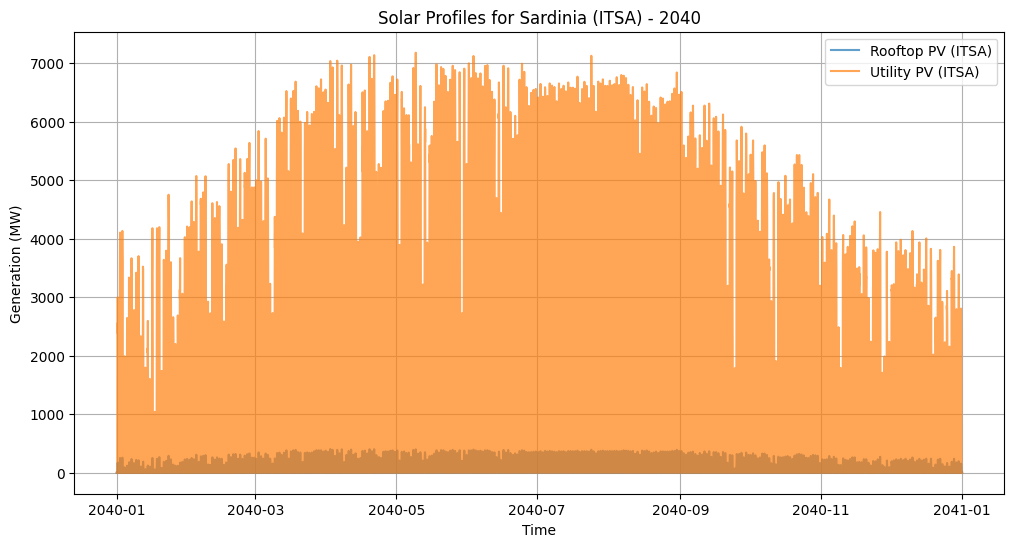

In [28]:
import matplotlib.pyplot as plt

if 'RES_profiles' not in locals() and 'RES_profiles' not in globals():
    print("❌ Error: 'RES_profiles' is not defined. Please run the previous cells to load the data first.")
else:
    # Plot solar profiles for Sardinia (ITSA)
    plt.figure(figsize=(12, 6))
    plt.plot(RES_profiles.index, RES_profiles['ITSA_Rooftop_PV'], label='Rooftop PV (ITSA)', alpha=0.7)
    plt.plot(RES_profiles.index, RES_profiles['ITSA_Utility_PV'], label='Utility PV (ITSA)', alpha=0.7)
    plt.title('Solar Profiles for Sardinia (ITSA) - 2040')
    plt.xlabel('Time')
    plt.ylabel('Generation (MW)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Wind - Offshore and Onshore

In [29]:
# Corrected Scaling for Wind Profiles
for z in zones:
    if z in capacities and 'Wind' in capacities[z]:
        wind_data = capacities[z]['Wind']
        onshore_cap = wind_data.get('Installed capacities Onshore wind (GW):', 0.0)
        offshore_cap = wind_data.get('Installed capacities Offshore wind (GW):', 0.0)

        onshore_col = f"{z}_Wind_Onshore"
        offshore_col = f"{z}_Wind_Offshore"

        if onshore_col in RES_profiles.columns:
            RES_profiles[onshore_col] = RES_profiles[onshore_col] * onshore_cap * 1e3
        if offshore_col in RES_profiles.columns:
            RES_profiles[offshore_col] = RES_profiles[offshore_col] * offshore_cap * 1e3

print("✅ Absolute wind profiles with corrected column mapping (MW).")

✅ Absolute wind profiles with corrected column mapping (MW).


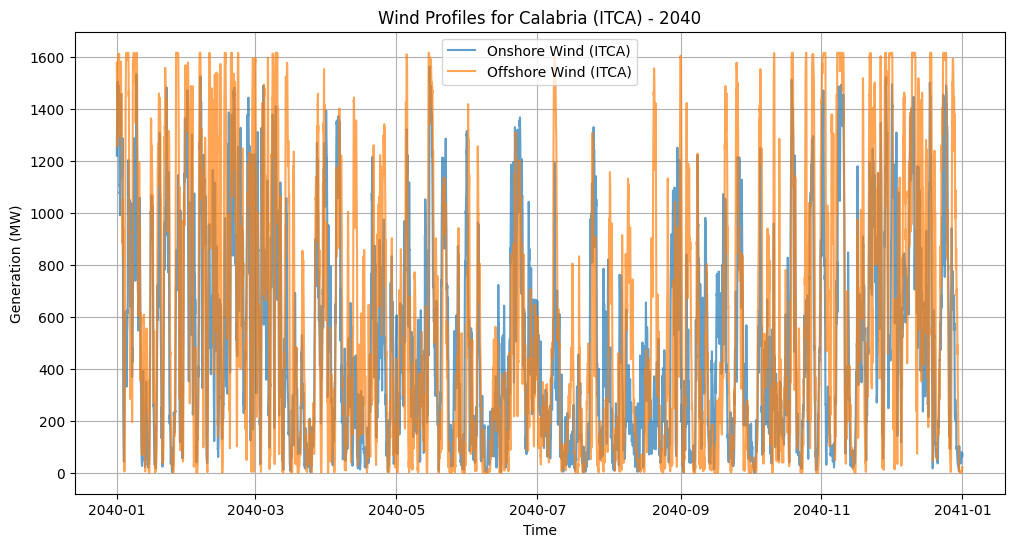

In [30]:
import matplotlib.pyplot as plt

if 'RES_profiles' not in locals() and 'RES_profiles' not in globals():
    print("❌ Error: 'RES_profiles' is not defined. Please run the previous cells to load the data first.")
else:
    # Plot wind profiles for Calabria (ITCA)
    plt.figure(figsize=(12, 6))

    # Check if the columns exist before plotting
    if 'ITCA_Wind_Onshore' in RES_profiles.columns:
        plt.plot(RES_profiles.index, RES_profiles['ITCA_Wind_Onshore'], label='Onshore Wind (ITCA)', alpha=0.7)
    if 'ITCA_Wind_Offshore' in RES_profiles.columns:
        plt.plot(RES_profiles.index, RES_profiles['ITCA_Wind_Offshore'], label='Offshore Wind (ITCA)', alpha=0.7)

    plt.title('Wind Profiles for Calabria (ITCA) - 2040')
    plt.xlabel('Time')
    plt.ylabel('Generation (MW)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Hydro - RoR, Pondage, Reservoir and Pump Storage

In [31]:
# Define keywords for hydro components, splitting PS into Open and Closed
hydro_keywords = ['RoR', 'Pondage', 'Res_', 'PS_Open', 'PS_Closed']

# Identify columns matching the keywords
hydro_columns = [col for col in RES_profiles.columns if any(kw in col for kw in hydro_keywords)]

# Group them by type for better visibility
print("Hydro-related Columns By Category:")
for kw in hydro_keywords:
    matches = [c for c in hydro_columns if kw in c]
    if matches:
        label = kw.replace('_', ' ')
        print(f"{label} related: {matches[:3]} ... (Total: {len(matches)})")

Hydro-related Columns By Category:
RoR related: ['AT00_RoR_MW', 'ITSI_RoR_MW', 'ITSA_RoR_MW'] ... (Total: 9)
Pondage related: ['AT00_Pondage_MW', 'ITSI_Pondage_MW', 'ITSA_Pondage_MW'] ... (Total: 9)
Res  related: ['AT00_Res_Inflow_MW', 'AT00_Res_Min_Turbine_MW', 'AT00_Res_Max_Turbine_MW'] ... (Total: 27)
PS Open related: ['AT00_PS_Open_Inflow_MW', 'AT00_PS_Open_Max_MW', 'ITSI_PS_Open_Inflow_MW'] ... (Total: 13)
PS Closed related: ['AT00_PS_Closed_Inflow_MW', 'AT00_PS_Closed_Max_MW', 'ITSI_PS_Closed_Inflow_MW'] ... (Total: 15)


In [32]:
# hydro paramteres for zone
selected_zone = "AT00"
capacities[selected_zone]['Hydro']

{'Run of River - Total turbining capacity (MW)': 5350.125759999998,
 'Pondage - Total reservoir capacity (GWh)': 5.332957,
 'Pondage - Total turbining capacity (MW)': 1149.307,
 'Reservoir - Total reservoir capacity (GWh)': 769.0365679999999,
 'Reservoir - Total turbining capacity (MW)': 2787.128999999999,
 'Pump Storage (open loop, with natural inflows) - Total reservoir capacity (GWh)': 1962.653,
 'Pump Storage (open loop, with natural inflows) - Total turbining capacity (MW)': 8082.5,
 'Pump Storage (open loop, with natural inflows) - Total pumping capacity (MW)': -7432.919999999999,
 'Pure Pump Storage (closed loop, no natural inflows) - Total reservoir capacity (GWh)': 3.6,
 'Pure Pump Storage (closed loop, no natural inflows) - Total turbining capacity (MW)': 450.0,
 'Pure Pump Storage (closed loop, no natural inflows) - Total pumping capacity (MW)': -450.0}

## Unflexible RES Sum

In [33]:
# Define the RES component suffixes to sum
unflex_res_components = ['Rooftop_PV', 'Utility_PV', 'Wind_Onshore', 'Wind_Offshore', 'RoR_MW', 'Other_RES']

total_res_columns = []

for z in zones:
    zone_cols = [f"{z}_{comp}" for comp in unflex_res_components if f"{z}_{comp}" in RES_profiles.columns]
    if zone_cols:
        RES_profiles[f"{z}_Nonflex_Total_RES"] = RES_profiles[zone_cols].sum(axis=1)
        total_res_columns.append(f"{z}_Nonflex_Total_RES")

# Fix: Display the columns from the DataFrame instead of calling .head() on the list
if total_res_columns:
    display(RES_profiles[total_res_columns].head(3))
else:
    print("No Nonflex_Total_RES columns were created.")

,AT00_Nonflex_Total_RES,ITSI_Nonflex_Total_RES,ITSA_Nonflex_Total_RES,ITCA_Nonflex_Total_RES,ITS1_Nonflex_Total_RES,ITCS_Nonflex_Total_RES,ITCN_Nonflex_Total_RES,ITN1_Nonflex_Total_RES,SI00_Nonflex_Total_RES
2040-01-01 00:00:00,4052.803001,4783.773034,4175.362576,3002.561495,11547.596945,7006.363172,3262.646478,3997.706233,167.813692
2040-01-01 01:00:00,4100.621813,4505.237300,4160.096640,3031.930702,11694.034422,6852.600197,3199.463882,3898.105945,166.732396
2040-01-01 02:00:00,3982.951088,4067.328122,4120.442617,3044.296016,11768.849289,6801.167513,3289.805503,3810.568549,168.309306


# Additional Inputs - Not Yet Defined

In [34]:
# Conventional electricty generators

conventional_mix_generator = {
    "AT00": {"coal": 0,   "gas_ccgt": 3500, "nuclear": 5000},
    "ITN1": {"coal": 0,   "gas_ccgt": 22000, "nuclear": 0},
    "ITCN": {"coal": 0,   "gas_ccgt": 3500,  "nuclear": 0},
    "ITCS": {"coal": 1900, "gas_ccgt": 4000,  "nuclear": 0},
    "ITS1":  {"coal":2500,   "gas_ccgt": 5500,  "nuclear": 0},
    "ITCA": {"coal": 0,   "gas_ccgt": 2800,  "nuclear": 0},
    "ITSI": {"coal": 0,   "gas_ccgt": 3200,  "nuclear": 0},
    "ITSA": {"coal": 1000, "gas_ccgt": 1200,  "nuclear": 0},
    "SI00": {"coal": 945,   "gas_ccgt": 945, "nuclear": 348}
}


In [35]:
### Adding NTC between national nodes

italian_h2_connections = [
    ("ITSI", "ITCA"),
    ("ITCA", "ITS1"),
    ("ITS1", "ITCS"),
    ("ITCS", "ITCN"),
    ("ITCN", "ITN1")
]

new_ntc_rows = []
for z1, z2 in italian_h2_connections:
    new_ntc_rows.append({
        'zone 1': z1,
        'zone 2': z2,
        'capacity_MW': 25000.0,
        'capacity_rev_MW': 25000.0,
        'efficiency': 0.99
    })

# Append to existing NTC_H2_df
if 'NTC_H2_df' in locals():
    NTC_H2_df = pd.concat([NTC_H2_df, pd.DataFrame(new_ntc_rows)], ignore_index=True)
else:
    NTC_H2_df = pd.DataFrame(new_ntc_rows)

print("✅ Successfully added internal Italian H2 NTCs.")
display(NTC_H2_df.tail(5))

✅ Successfully added internal Italian H2 NTCs.


,zone 1,zone 2,capacity_MW,capacity_rev_MW,efficiency
1,ITSI,ITCA,25000.0,25000.0,0.99
2,ITCA,ITS1,25000.0,25000.0,0.99
3,ITS1,ITCS,25000.0,25000.0,0.99
4,ITCS,ITCN,25000.0,25000.0,0.99
5,ITCN,ITN1,25000.0,25000.0,0.99


Average Hourly Demands per Zone (MW):


type,CH4_heat,El_market,El_prosumer,H2_heat,H2_zone_1,H2_zone_2,SNG,eDiesel,eKerosine
zone,,,,,,,,,
AT00,0,8341,3828,2227,1282,4350,0,0,0
ITCA,203,397,368,176,0,0,0,0,0
ITCN,945,1847,1718,819,0,0,0,0,0
ITCS,1815,3643,3379,1571,0,0,0,0,0
ITN1,6325,11750,10931,5496,2295,9148,0,0,0
ITS1,741,1512,1392,641,0,0,0,0,0
ITSA,349,1044,318,302,0,0,0,0,0
ITSI,616,1286,1192,532,0,0,0,0,0
SI00,301,995,727,229,132,446,0,0,0


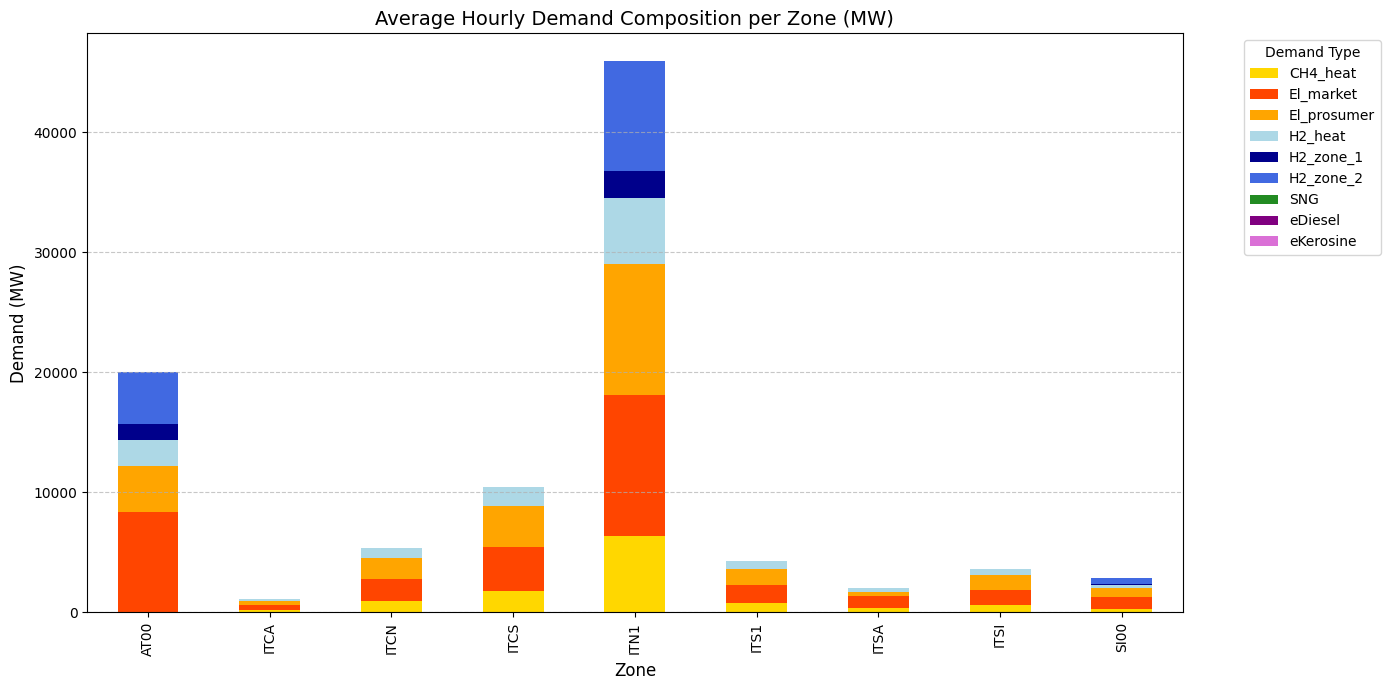

In [36]:
# 1. Calculate the mean of all demand columns
demand_means = demand_profiles.mean()

# 2. Extract zone and demand type from the index
demand_df = demand_means.reset_index()
demand_df.columns = ['column', 'MW']
demand_df['zone'] = demand_df['column'].apply(lambda x: x.split('_')[0])
demand_df['type'] = demand_df['column'].apply(lambda x: '_'.join(x.split('_')[1:]))

# 3. Pivot the data
demand_pivot = demand_df.pivot(index='zone', columns='type', values='MW').fillna(0)
demand_pivot = demand_pivot.astype(int)

# 4. Define Color Mapping for Commodities
# Hydrogen: Blues, Gas: Yellow, Electricity: Oranges/Reds, Synfuels: Greens/Purples
color_map = {
    'CH4_heat': '#FFD700',    # Gold/Yellow
    'H2_heat': '#add8e6',     # Light Blue
    'H2_zone_1': '#00008b',   # Dark Blue
    'H2_zone_2': '#4169e1',   # Royal Blue
    'El_market': '#ff4500',   # OrangeRed
    'El_prosumer': '#ffa500', # Orange
    'SNG': '#228b22',         # Forest Green
    'eDiesel': '#800080',     # Purple
    'eKerosine': '#da70d6'    # Orchid
}

# Match colors to current pivot columns
colors = [color_map.get(col, '#333333') for col in demand_pivot.columns]

# 5. Display the table
print("Average Hourly Demands per Zone (MW):")
display(demand_pivot)

# 6. Plotting with custom colors
ax = demand_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
plt.title("Average Hourly Demand Composition per Zone (MW)", fontsize=14)
plt.ylabel("Demand (MW)", fontsize=12)
plt.xlabel("Zone", fontsize=12)
plt.legend(title="Demand Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Models

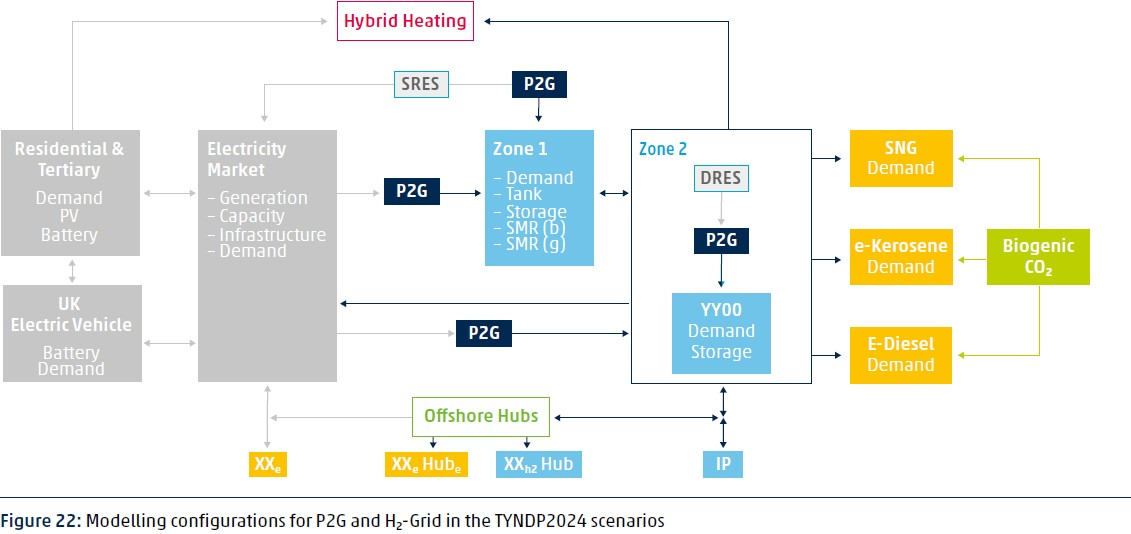

## Model Data

### Demand file

In [37]:
# Map zones to model_data
model_data = {z: {} for z in zones}
print(f"✅ Initialized model_data with zones: {list(model_data.keys())}")

✅ Initialized model_data with zones: ['AT00', 'ITSI', 'ITSA', 'ITCA', 'ITS1', 'ITCS', 'ITCN', 'ITN1', 'SI00']


In [38]:
# Demand Data import to Input_data
for z in zones:
    # Find all columns in demand_profiles that start with the zone prefix
    zone_cols = [col for col in demand_profiles.columns if col.startswith(f"{z}_")]

    for col in zone_cols:
        # Remove the zone prefix for cleaner keys in the dictionary
        profile_key = col.replace(f"{z}_", "", 1)
        model_data[z][profile_key] = demand_profiles[col]

print("✅ Successfully added all demand profiles to a clean input_data dictionary.")

# Verify the keys for the first zone to ensure it worked
first_zone = zones[0]
print(f"\nKeys in model_data['{first_zone}']: {list(model_data[first_zone].keys())}")


✅ Successfully added all demand profiles to a clean input_data dictionary.

Keys in model_data['AT00']: ['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine']


### Nonflex_Total_RES

In [39]:
# Add _Nonflex_Total_RES per zone to the model_data dictionary
for z in zones:
    col_name = f"{z}_Nonflex_Total_RES"
    if col_name in RES_profiles.columns:
        model_data[z]['Nonflex_Total_RES'] = RES_profiles[col_name]
    else:
        print(f"⚠️ Warning: Column {col_name} not found in RES_profiles.")

print("✅ Successfully added Nonflex_Total_RES to the model_data dictionary.")

# Verify the updated keys for the first zone
first_zone = zones[0]
print(f"\nUpdated keys in model_data['{first_zone}']: {list(model_data[first_zone].keys())}")

✅ Successfully added Nonflex_Total_RES to the model_data dictionary.

Updated keys in model_data['AT00']: ['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine', 'Nonflex_Total_RES']


### Electrolysers - SRES and DRES

In [40]:
# Define the share parameter
share = input_data['share']

for z in zones:
    # 1. Add the share parameter and calculate SRES/DRES profiles
    model_data[z]['share'] = share

    if 'Nonflex_Total_RES' in model_data[z]:
        Nonflex_Total_RES = model_data[z]['Nonflex_Total_RES']
        model_data[z]['SRES'] = Nonflex_Total_RES * share
        model_data[z]['DRES'] = Nonflex_Total_RES * (1 - share)
    else:
        print(f"⚠️ Warning: 'Nonflex_Total_RES' not found for zone {z}.")

    # 2. Extract Electrolyser Capacities and Efficiencies from the capacities dictionary
    if z in capacities and 'Electrolyser' in capacities[z]:
        ely_data = capacities[z]['Electrolyser']

        # Capacities
        total_ely_cap = ely_data.get('Net maximum capacity \n(MW)', 0.0)
        model_data[z]['SRES_electrolyser'] = total_ely_cap * share
        model_data[z]['DRES_electrolyser'] = total_ely_cap * (1 - share)

        # Efficiency - If 0 or missing, default to 0.68
        eff = ely_data.get('Average efficiency', 0.68)
        if eff <= 0:
            print(f"ℹ️ Adjusted efficiency for {z} electrolyser from {eff} to 0.68")
            eff = 0.68

        model_data[z]['elec_efficiency'] = eff

    else:
        print(f"⚠️ Warning: Electrolyser data not found for zone {z} in capacities.")

print("✅ Successfully updated model_data with shares, SRES/DRES profiles, and corrected electrolyzer efficiencies.")

ℹ️ Adjusted efficiency for SI00 electrolyser from 0 to 0.68
✅ Successfully updated model_data with shares, SRES/DRES profiles, and corrected electrolyzer efficiencies.


### SMR

In [41]:
# Update SMR capacities in model_data using smr_capacities DataFrame
# If a country has multiple zones, divide the total capacity equally among them

# 1. Count zones per country prefix
from collections import Counter
country_counts = Counter(z[:2] for z in zones)

for zone in zones:
    country_code = zone[:2]
    num_zones = country_counts[country_code]

    # Initialize with 0 to ensure keys exist
    model_data[zone]['SMR_g_zone1'] = 0.0
    model_data[zone]['SMR_b_zone1'] = 0.0

    if country_code in smr_capacities.index:
        row = smr_capacities.loc[country_code]
        # Divide total capacity by the number of zones in that country
        capacity_per_zone = row['CAPACITY [MW]'] / num_zones
        ccs_enabled = row['CCS']

        if ccs_enabled:
            # If CCS is True, it's Blue SMR
            model_data[zone]['SMR_b_zone1'] = capacity_per_zone
        else:
            # If CCS is False, it's Grey SMR
            model_data[zone]['SMR_g_zone1'] = capacity_per_zone

print(f"✅ Successfully extended model_data with SMR capacities (split across {len(zones)} zones).")

# Verification: Display the split entries
smr_summary = {z: {'Grey': model_data[z]['SMR_g_zone1'], 'Blue': model_data[z]['SMR_b_zone1']} for z in zones}
display(pd.DataFrame(smr_summary).T.round(2))

✅ Successfully extended model_data with SMR capacities (split across 9 zones).


,Grey,Blue
AT00,423.35,0.00
ITSI,0.00,383.57
ITSA,0.00,383.57
ITCA,0.00,383.57
ITS1,0.00,383.57
ITCS,0.00,383.57
ITCN,0.00,383.57
ITN1,0.00,383.57
SI00,0.00,0.00


### H2 storage

In [42]:
h2_storage

,NODE,YEAR,SCENARIO,H2 ZONE,CAPACITY [GWh],MAX POWER [MW],MAX LOAD [MW],MAX CAPACITY [GWh],MAX POWER EXPANSION [MW],MAX LOAD EXPANSION [MW],CHARGE EFFICIENCY [%],DISCHARGE EFFICIENCY [%]
0,AT,2040,All,ZONE 2,0.000000,0.00000,0.000000,5235.492341,1388.440833,1388.440833,99,100
1,IT,2040,All,ZONE 2,5180.000000,2005.01425,3204.038625,5180.000000,2005.014250,3204.038625,99,100
2,SI,2040,All,ZONE 2,0.000000,0.00000,0.000000,388.063711,283.602125,276.881708,99,100
3,AT,2040,Global Ambition,ZONE 1,8.630246,359.59360,359.593600,NaN,NaN,NaN,99,100
4,IT,2040,Global Ambition,ZONE 1,35.329840,1472.07600,1472.076000,NaN,NaN,NaN,99,100
5,SI,2040,Global Ambition,ZONE 1,1.566051,65.25214,65.252140,NaN,NaN,NaN,99,100


In [43]:
# Map H2 Storage capacities (Energy and Power) to model_data
# Units in data: Energy in GWh (converted to MWh), Power in MW

for zone in zones:
    country_code = zone[:2]

    # Initialize values
    model_data[zone]['H2_storage_energy_z1'] = 0.0
    model_data[zone]['H2_storage_energy_z2'] = 0.0
    model_data[zone]['H2_storage_p_max_z1'] = 0.0
    model_data[zone]['H2_storage_p_max_z2'] = 0.0
    model_data[zone]['H2_storage_p_load_z1'] = 0.0
    model_data[zone]['H2_storage_p_load_z2'] = 0.0

    # Filter h2_storage for the specific country
    country_data = h2_storage[h2_storage['NODE'] == country_code]

    # Map Zone 1 (Distributed/Tank)
    z1_mask = country_data['H2 ZONE'] == 'ZONE 1'
    if z1_mask.any():
        z1_row = country_data[z1_mask].iloc[0]
        e_val = z1_row['CAPACITY [GWh]']
        p_max = z1_row.get('MAX POWER [MW]', 0.0)
        p_load = z1_row.get('MAX LOAD [MW]', 0.0)

        if country_code == 'IT':
            model_data[zone]['H2_storage_energy_z1'] = (e_val * 1e3) / 7
            model_data[zone]['H2_storage_p_max_z1'] = p_max / 7
            model_data[zone]['H2_storage_p_load_z1'] = p_load / 7
        else:
            model_data[zone]['H2_storage_energy_z1'] = e_val * 1e3
            model_data[zone]['H2_storage_p_max_z1'] = p_max
            model_data[zone]['H2_storage_p_load_z1'] = p_load

    # Map Zone 2 (Caverns/Large scale)
    z2_mask = country_data['H2 ZONE'] == 'ZONE 2'
    if z2_mask.any():
        z2_row = country_data[z2_mask].iloc[0]
        e_val = z2_row['CAPACITY [GWh]']
        p_max = z2_row.get('MAX POWER [MW]', 0.0)
        p_load = z2_row.get('MAX LOAD [MW]', 0.0)

        if country_code == 'IT':
            model_data[zone]['H2_storage_energy_z2'] = (e_val * 1e3) / 7
            model_data[zone]['H2_storage_p_max_z2'] = p_max / 7
            model_data[zone]['H2_storage_p_load_z2'] = p_load / 7
        else:
            model_data[zone]['H2_storage_energy_z2'] = e_val * 1e3
            model_data[zone]['H2_storage_p_max_z2'] = p_max
            model_data[zone]['H2_storage_p_load_z2'] = p_load

print('✅ Successfully added H2 storage energy and power capacities to model_data.')

# Verification for a sample zone
sample_z = 'ITN1'
print(f'\n{sample_z} Storage Z1 -> Energy: {model_data[sample_z]["H2_storage_energy_z1"]:.2f} MWh, P_max: {model_data[sample_z]["H2_storage_p_max_z1"]:.2f} MW')

✅ Successfully added H2 storage energy and power capacities to model_data.

ITN1 Storage Z1 -> Energy: 5047.12 MWh, P_max: 210.30 MW


In [44]:
import pandas as pd

# Extract H2 storage data for all zones from model_data
h2_storage_summary = []

for zone in zones:
    z_data = model_data.get(zone, {})
    h2_storage_summary.append({
        'Zone': zone,
        'Z1 Energy [MWh]': z_data.get('H2_storage_energy_z1', 0),
        'Z1 Discharging (Max Power) [MW]': z_data.get('H2_storage_p_max_z1', 0),
        'Z1 Charging (Max Load) [MW]': z_data.get('H2_storage_p_load_z1', 0),
        'Z2 Energy [MWh]': z_data.get('H2_storage_energy_z2', 0),
        'Z2 Discharging (Max Power) [MW]': z_data.get('H2_storage_p_max_z2', 0),
        'Z2 Charging (Max Load) [MW]': z_data.get('H2_storage_p_load_z2', 0)
    })

# Create DataFrame
df_h2_storage_data = pd.DataFrame(h2_storage_summary).set_index('Zone')

print("Detailed Hydrogen Storage Data per Zone:")
display(df_h2_storage_data.round(2))

Detailed Hydrogen Storage Data per Zone:


,Z1 Energy [MWh],Z1 Discharging (Max Power) [MW],Z1 Charging (Max Load) [MW],Z2 Energy [MWh],Z2 Discharging (Max Power) [MW],Z2 Charging (Max Load) [MW]
Zone,,,,,,
AT00,8630.25,359.59,359.59,0.0,0.00,0.00
ITSI,5047.12,210.30,210.30,740000.0,286.43,457.72
ITSA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITS1,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCS,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCN,5047.12,210.30,210.30,740000.0,286.43,457.72
ITN1,5047.12,210.30,210.30,740000.0,286.43,457.72
SI00,1566.05,65.25,65.25,0.0,0.00,0.00


In [45]:
import pandas as pd

# Extract H2 storage related data from model_data for each zone
h2_storage_summary = []

for zone in zones:
    z_data = model_data.get(zone, {})
    h2_storage_summary.append({
        'Zone': zone,
        'Energy Z1 [MWh]': z_data.get('H2_storage_energy_z1', 0),
        'Power Max Z1 [MW]': z_data.get('H2_storage_p_max_z1', 0),
        'Power Load Z1 [MW]': z_data.get('H2_storage_p_load_z1', 0),
        'Energy Z2 [MWh]': z_data.get('H2_storage_energy_z2', 0),
        'Power Max Z2 [MW]': z_data.get('H2_storage_p_max_z2', 0),
        'Power Load Z2 [MW]': z_data.get('H2_storage_p_load_z2', 0)
    })

# Create and display the summary table
df_h2_storage_info = pd.DataFrame(h2_storage_summary).set_index('Zone')
print("Hydrogen Storage Parameters in model_data per Zone:")
display(df_h2_storage_info.round(2))

Hydrogen Storage Parameters in model_data per Zone:


,Energy Z1 [MWh],Power Max Z1 [MW],Power Load Z1 [MW],Energy Z2 [MWh],Power Max Z2 [MW],Power Load Z2 [MW]
Zone,,,,,,
AT00,8630.25,359.59,359.59,0.0,0.00,0.00
ITSI,5047.12,210.30,210.30,740000.0,286.43,457.72
ITSA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITS1,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCS,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCN,5047.12,210.30,210.30,740000.0,286.43,457.72
ITN1,5047.12,210.30,210.30,740000.0,286.43,457.72
SI00,1566.05,65.25,65.25,0.0,0.00,0.00


In [46]:
import pandas as pd

summary_data = []

for z in zones:
    z_data = model_data.get(z, {})

    # Calculate average hourly demands (handling potential missing keys or scalar types)
    h2_z1 = z_data.get('H2_zone_1', pd.Series([0])).mean() if isinstance(z_data.get('H2_zone_1'), pd.Series) else z_data.get('H2_zone_1', 0)
    h2_z2 = z_data.get('H2_zone_2', pd.Series([0])).mean() if isinstance(z_data.get('H2_zone_2'), pd.Series) else z_data.get('H2_zone_2', 0)
    ekero = z_data.get('eKerosine', pd.Series([0])).mean() if isinstance(z_data.get('eKerosine'), pd.Series) else z_data.get('eKerosine', 0)
    edies = z_data.get('eDiesel', pd.Series([0])).mean() if isinstance(z_data.get('eDiesel'), pd.Series) else z_data.get('eDiesel', 0)
    sng = z_data.get('SNG', pd.Series([0])).mean() if isinstance(z_data.get('SNG'), pd.Series) else z_data.get('SNG', 0)

    # Extract scalar capacity
    dres_ely = z_data.get('DRES_electrolyser', 0)

    summary_data.append({
        'Zone': z,
        'H2 Demand Zone 1 (MW)': h2_z1,
        'H2 Demand Zone 2 (MW)': h2_z2,
        'eKerosine Demand (MW)': ekero,
        'eDiesel Demand (MW)': edies,
        'SNG Demand (MW)': sng,
        'DRES Electrolyser Cap (MW)': dres_ely
    })

summary_df = pd.DataFrame(summary_data).set_index('Zone')

print("Average Hourly Demands and DRES Electrolyser Capacities per Zone:")
display(summary_df.round(2))


Average Hourly Demands and DRES Electrolyser Capacities per Zone:


,H2 Demand Zone 1 (MW),H2 Demand Zone 2 (MW),eKerosine Demand (MW),eDiesel Demand (MW),SNG Demand (MW),DRES Electrolyser Cap (MW)
Zone,,,,,,
AT00,1282.72,4350.24,0.02,0.02,0.01,3429.60
ITSI,0.00,0.00,0.02,0.02,0.01,643.66
ITSA,0.00,0.00,0.02,0.02,0.01,879.25
ITCA,0.00,0.00,0.02,0.02,0.01,477.60
ITS1,0.00,0.00,0.02,0.02,0.01,1917.70
ITCS,0.00,0.00,0.02,0.02,0.01,429.11
ITCN,0.00,0.00,0.02,0.02,0.01,94.84
ITN1,2295.98,9148.63,0.02,0.02,0.01,557.84
SI00,132.91,446.67,0.02,0.02,0.01,1123.00


### Conventional Generators

In [47]:
# Add Coal, Gas_CCGT, and Nuclear values to model_data
for zone in zones:
    if zone in conventional_mix_generator:
        mix = conventional_mix_generator[zone]
        model_data[zone]['coal'] = mix.get('coal', 0)
        model_data[zone]['gas_ccgt'] = mix.get('gas_ccgt', 0)
        model_data[zone]['nuclear'] = mix.get('nuclear', 0)
    else:
        print(f"⚠️ Warning: No data found for zone {zone} in conventional_mix_generator.")

print("\n✅ Successfully updated model_data with conventional generation electricity powers.")


✅ Successfully updated model_data with conventional generation electricity powers.


Average Hourly Generation Potential/Capacity per Zone (MW):


,SRES,COAL,NUCLEAR,CCGT,DRES
zone,,,,,
AT00,6380,0,5000,3500,6380
ITSI,2492,0,0,3200,2492
ITSA,1741,1000,0,1200,1741
ITCA,1218,0,0,2800,1218
ITS1,4068,2500,0,5500,4068
ITCS,3341,1900,0,4000,3341
ITCN,1464,0,0,3500,1464
ITN1,4132,0,0,22000,4132
SI00,444,945,348,945,444


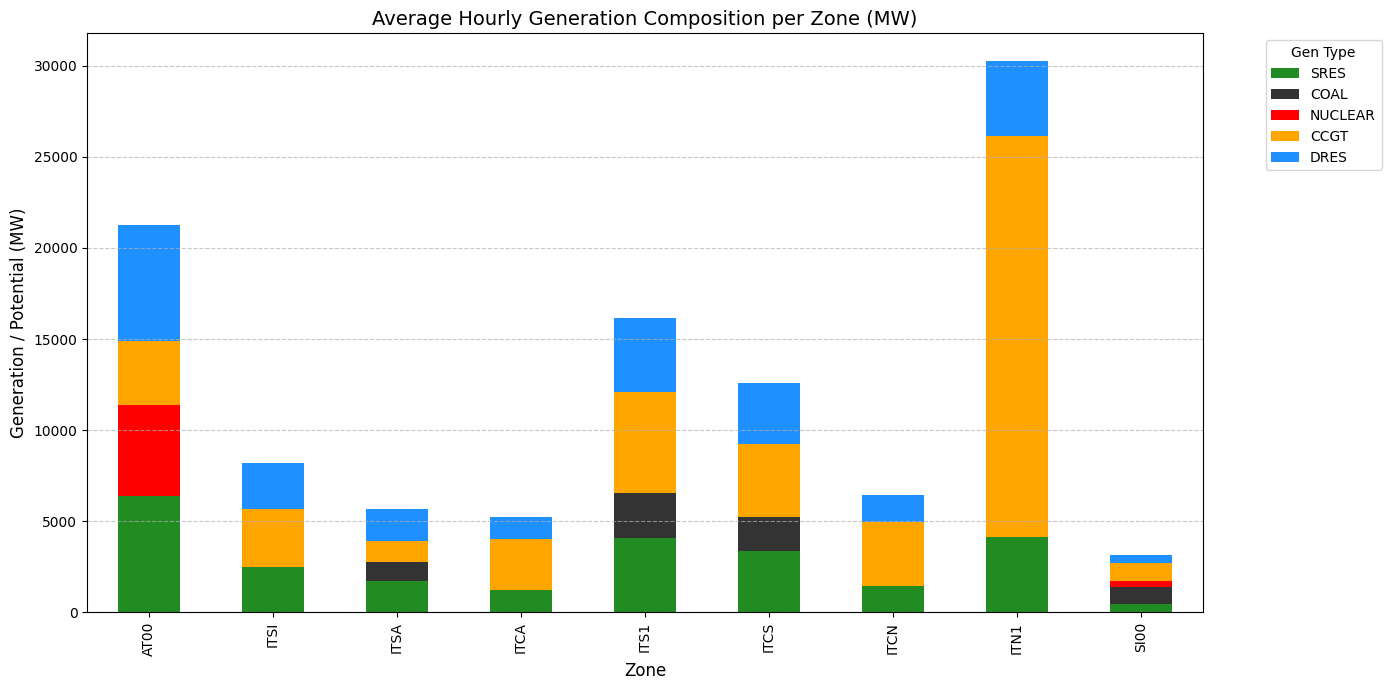

In [48]:
# 1. Prepare the generation data using model_data and conventional_mix_generator
gen_stats = []

for z in zones:
    # Get conventional capacities from the updated dictionary
    mix = conventional_mix_generator.get(z, {})

    # Get RES profile means from model_data
    z_data = model_data.get(z, {})

    # Handle case where profiles might be Series or scalar
    sres_val = z_data.get('SRES', 0)
    if isinstance(sres_val, pd.Series): sres_val = sres_val.mean()

    dres_val = z_data.get('DRES', 0)
    if isinstance(dres_val, pd.Series): dres_val = dres_val.mean()

    gen_stats.append({
        'zone': z,
        'SRES': int(sres_val),
        'COAL': int(mix.get('coal', 0)),
        'NUCLEAR': int(mix.get('nuclear', 0)),
        'CCGT': int(mix.get('gas_ccgt', 0)),
        'DRES': int(dres_val)
    })

gen_df = pd.DataFrame(gen_stats).set_index('zone').fillna(0)

# 2. Display the table
print("Average Hourly Generation Potential/Capacity per Zone (MW):")
display(gen_df)

# 3. Define Color Mapping
gen_colors = {
    'SRES': '#228b22',    # Forest Green
    'COAL': '#333333',    # Dark Grey
    'NUCLEAR': '#ff0000', # Red
    'CCGT': '#ffa500',    # Orange
    'DRES': '#1e90ff'     # Dodger Blue
}

colors = [gen_colors[col] for col in gen_df.columns]

# 4. Plotting
ax = gen_df.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
plt.title("Average Hourly Generation Composition per Zone (MW)", fontsize=14)
plt.ylabel("Generation / Potential (MW)", fontsize=12)
plt.xlabel("Zone", fontsize=12)
plt.legend(title="Gen Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd

zone = 'AT00'
res_col = f"{zone}_Nonflex_Total_RES"

if res_col in RES_profiles.columns:
    max_res = RES_profiles[res_col].max()
    mean_res = RES_profiles[res_col].mean()

    print(f"--- RES Analysis for {zone} ---")
    print(f"Maximum Hourly Generation (Peak): {max_res:,.2f} MW")
    print(f"Average Hourly Generation (Mean): {mean_res:,.2f} MW")
    print(f"Implied Capacity Factor: {(mean_res/max_res)*100:.2f}%")
else:
    print(f"Column {res_col} not found in RES_profiles.")

--- RES Analysis for AT00 ---
Maximum Hourly Generation (Peak): 38,004.57 MW
Average Hourly Generation (Mean): 12,761.53 MW
Implied Capacity Factor: 33.58%


In [50]:
import pandas as pd

demand_summary = []
for z in zones:
    if 'El_market' in model_data[z]:
        series = model_data[z]['El_market']
        avg_mw = series.mean()
        total_twh = series.sum() / 1e6 # MW * h / 1,000,000 = TWh
        demand_summary.append({
            'Zone': z,
            'Avg Hourly Demand (MW)': avg_mw,
            'Annual Demand (TWh)': total_twh
        })

df_demand = pd.DataFrame(demand_summary).set_index('Zone')
print(f"Electricity Demand Summary ({scenario} {year}):")
display(df_demand.round(2))

Electricity Demand Summary (GA 2040):


,Avg Hourly Demand (MW),Annual Demand (TWh)
Zone,,
AT00,8341.82,73.27
ITSI,1286.61,11.30
ITSA,1044.04,9.17
ITCA,397.57,3.49
ITS1,1512.68,13.29
ITCS,3643.60,32.01
ITCN,1847.16,16.23
ITN1,11750.88,103.22
SI00,995.66,8.75


## Dual Network Model

In [51]:
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. INITIALIZE NETWORK
n_dual = pypsa.Network()
n_dual.set_snapshots(RES_profiles.index)

# Add Energy Carriers
carriers = ["AC", "H2", "natural_gas", "CO2", "SNG", "e-Kerosene", "e-Diesel", "coal", "hydro", "battery", "nuclear"]
for c in carriers:
    n_dual.add("Carrier", c)

# Global market for coal
n_dual.add("Bus", "EU_coal_market", carrier="coal")
n_dual.add("Generator", "Global_Coal_Import", bus="EU_coal_market", p_nom_extendable=True, marginal_cost=25)

# 2. BUILD FULLY INTEGRATED ZONAL NETWORKS
for zone, z_data in model_data.items():
    # --- BUSES ---
    elec_bus = f"{zone}_electricity_market"
    n_dual.add("Bus", elec_bus, carrier="AC")
    n_dual.add("Bus", f"{zone}_gas_bus", carrier="natural_gas")

    if input_data.get('H2', False):
        n_dual.add("Bus", f"{zone}_SRES_AC", carrier="AC")
        n_dual.add("Bus", f"{zone}_DRES_AC", carrier="AC")
        n_dual.add("Bus", f"{zone}_h2_zone1", carrier="H2")
        n_dual.add("Bus", f"{zone}_h2_zone2", carrier="H2")
        if input_data.get('Synthetic_fuels', False):
          n_dual.add("Bus", f"{zone}_bio_co2", carrier="CO2")
          n_dual.add("Bus", f"{zone}_sng_bus", carrier="SNG")
          n_dual.add("Bus", f"{zone}_ekerosene_bus", carrier="e-Kerosene")
          n_dual.add("Bus", f"{zone}_ediesel_bus", carrier="e-Diesel")

    # --- GAS source ---
    n_dual.add("Generator", f"{zone}_Gas_Source", bus=f"{zone}_gas_bus", carrier="natural_gas", p_nom_extendable=True, marginal_cost=40)

    # --- E L E C T R I C I T Y   M O D E L ---
    # --- Conventional electricity generators ---
    if z_data.get('gas_ccgt', 0) > 0:
        n_dual.add("Link", f"{zone}_CCGT_Plant", bus0=f"{zone}_gas_bus", bus1=elec_bus, p_nom=z_data['gas_ccgt'], efficiency=0.55)

    if z_data.get('coal', 0) > 0:
        # Coal Ramping: 12 hours to full capacity -> 1/12 per hour
        n_dual.add("Link", f"{zone}_Coal_Plant", bus0="EU_coal_market", bus1=elec_bus, p_nom=z_data['coal'], efficiency=0.40, ramp_limit_up=1/12, ramp_limit_down=1/12)

    if z_data.get('nuclear', 0) > 0:
        # Nuclear Ramping: 48 hours to full capacity -> 1/48 per hour
        n_dual.add("Generator", f"{zone}_Nuclear_Plant", bus=elec_bus, carrier="nuclear", p_nom=z_data['nuclear'], marginal_cost=12.0, ramp_limit_up=1/48, ramp_limit_down=1/48)

    # --- Storage Assets ---
    if input_data.get('FLEX', True):
        if zone in capacities:
            caps = capacities[zone]
            if 'Hydro' in caps:
                h = caps['Hydro']
                p_res = h.get('Reservoir - Total turbining capacity (MW)', 0)
                if p_res > 0:
                    n_dual.add("StorageUnit", f"{zone}_HPP_Reservoir", bus=elec_bus, carrier="hydro", p_nom=p_res,
                          max_hours=(h.get('Reservoir - Total reservoir capacity (GWh)', 0)*1e3)/p_res,
                          cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                          p_max_pu=RES_profiles[f"{zone}_Res_Inflow_MW"]/p_res if f"{zone}_Res_Inflow_MW" in RES_profiles.columns else 0)
                p_pond = h.get('Pondage - Total turbining capacity (MW)', 0)
                if p_pond > 0:
                    n_dual.add("StorageUnit", f"{zone}_HPP_Pondage", bus=elec_bus, carrier="hydro", p_nom=p_pond,
                    max_hours=(h.get('Pondage - Total reservoir capacity (GWh)', 0)*1e3)/p_pond,
                    cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                    p_max_pu=RES_profiles[f"{zone}_Pondage_MW"]/p_pond if f"{zone}_Pondage_MW" in RES_profiles.columns else 0)
                p_open = h.get('Pump Storage (open loop, with natural inflows) - Total turbining capacity (MW)', 0)
                if p_open > 0:
                    p_pump = abs(h.get('Pump Storage (open loop, with natural inflows) - Total pumping capacity (MW)', 0))
                    n_dual.add("StorageUnit", f"{zone}_PHS_Open", bus=elec_bus, carrier="hydro", p_nom=p_open, p_max_pu_store=p_pump/p_open,
                    max_hours=(h.get('Pump Storage (open loop, with natural inflows) - Total reservoir capacity (GWh)', 0)*1e3)/p_open,
                      cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)
                p_closed = h.get('Pure Pump Storage (closed loop, no natural inflows) - Total turbining capacity (MW)', 0)
                if p_closed > 0:
                    p_pump_c = abs(h.get('Pure Pump Storage (closed loop, no natural inflows) - Total pumping capacity (MW)', 0))
                    n_dual.add("StorageUnit", f"{zone}_PHS_Closed", bus=elec_bus, carrier="hydro", p_nom=p_closed, p_max_pu_store=p_pump_c/p_closed,
                          max_hours=(h.get('Pure Pump Storage (closed loop, no natural inflows) - Total reservoir capacity (GWh)', 0)*1e3)/p_closed,
                          cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)
            # Battery Model
            if 'Battery' in caps:
                b = caps['Battery']
                p_bat = b.get('Net maximum capacity - generation perspective \n(MW)', 0)
                if p_bat > 0:
                    n_dual.add("StorageUnit", f"{zone}_Battery", bus=elec_bus, carrier="battery", p_nom=p_bat,
                          p_max_pu_store=abs(b.get('Net maximum capacity - demand perspective \n(MW)', 0))/p_bat,
                          max_hours=b.get('Storage capacity \n(MWh)', 0)/p_bat, cyclic_state_of_charge=True, efficiency_dispatch=0.95, efficiency_store=0.95)

    # --- Electricity loads ---
    n_dual.add("Load", f"{zone}_elec_demand", bus=elec_bus, p_set=z_data['El_market'])

    # --- H Y D R O G E N   M O D E L ---
    if input_data.get('H2', False):
        # SMR Links
        if z_data.get('SMR_g_zone1', 0) > 0:
            n_dual.add("Link", f"{zone}_SMR_Grey", bus0=f"{zone}_gas_bus", bus1=f"{zone}_h2_zone1", p_nom=z_data['SMR_g_zone1'], efficiency=0.70, marginal_cost=5.0)
        if z_data.get('SMR_b_zone1', 0) > 0:
            n_dual.add("Link", f"{zone}_SMR_Blue", bus0=f"{zone}_gas_bus", bus1=f"{zone}_h2_zone1", p_nom=z_data['SMR_b_zone1'], efficiency=0.65, marginal_cost=15.0)

        if 'SRES' in z_data:
            # SRES generation on SRES bus
            n_dual.add("Generator", f"{zone}_SRES_plant", bus=f"{zone}_SRES_AC", carrier="AC", p_nom=1, p_max_pu=z_data['SRES'], marginal_cost=4.6)
            # bidirectional electricity market grid <--> SRES bus
            n_dual.add("Link", f"{zone}_SRES_to_mgrid", bus0=f"{zone}_SRES_AC", bus1=elec_bus, p_nom=1e6, efficiency=1.0)
            n_dual.add("Link", f"{zone}_mgrid_to_SRES", bus0=elec_bus, bus1=f"{zone}_SRES_AC", p_nom=1e6, efficiency=1.0)

        if 'DRES' in z_data:
            n_dual.add("Generator", f"{zone}_DRES_plant", bus=f"{zone}_DRES_AC", carrier="AC", p_nom=1, p_max_pu=z_data['DRES'], marginal_cost=4.6)
            n_dual.add("Link", f"{zone}_mgrid_to_DRES", bus0=elec_bus, bus1=f"{zone}_DRES_AC", p_nom=1e6, efficiency=1.0)

        # Electrolysers
        if z_data.get('SRES_electrolyser', 0) > 0:
            n_dual.add("Link", f"{zone}_SRES_Electrolyser", bus0=f"{zone}_SRES_AC", bus1=f"{zone}_h2_zone1",
                       p_nom=z_data['SRES_electrolyser'], efficiency=z_data.get('elec_efficiency', 0.68))
        if z_data.get('DRES_electrolyser', 0) > 0:
            n_dual.add("Link", f"{zone}_DRES_Electrolyser", bus0=f"{zone}_DRES_AC", bus1=f"{zone}_h2_zone2",
                       p_nom=z_data['DRES_electrolyser'], efficiency=z_data.get('elec_efficiency', 0.68))

        # H2 Storage
        if input_data.get('FLEX', True):
            if z_data.get('H2_storage_p_max_z1', 0) > 0:
                n_dual.add("StorageUnit", f"{zone}_H2_Storage_Z1", bus=f"{zone}_h2_zone1", carrier="H2",
                p_nom=z_data['H2_storage_p_max_z1'],
                max_hours=z_data.get('H2_storage_energy_z1', 0)/z_data['H2_storage_p_max_z1'],
                cyclic_state_of_charge=True, efficiency_dispatch=0.97, efficiency_store=0.98)
            if z_data.get('H2_storage_p_max_z2', 0) > 0:
            #    # p_nom = discharging capacity, p_max_pu_store = charging/discharging ratio
                n_dual.add("StorageUnit", f"{zone}_H2_Storage_Z2", bus=f"{zone}_h2_zone2", carrier="H2",
                p_nom=z_data['H2_storage_p_max_z2'],
                p_max_pu_store=z_data['H2_storage_p_load_z2'] / z_data['H2_storage_p_max_z2'],
                max_hours=z_data['H2_storage_energy_z2'] / z_data['H2_storage_p_max_z2'],
                cyclic_state_of_charge=True, efficiency_dispatch=0.97, efficiency_store=0.98)

        # H2 Demand & Slack
        if 'H2_zone_1' in z_data:
             n_dual.add("Load", f"{zone}_H2_Demand_Z1", bus=f"{zone}_h2_zone1", p_set=z_data['H2_zone_1'])
             n_dual.add("Generator", f"{zone}_H2_Slack_Z1", bus=f"{zone}_h2_zone1", carrier="H2", p_nom_extendable=True, marginal_cost=1e3)
        if 'H2_zone_2' in z_data:
             n_dual.add("Load", f"{zone}_H2_Demand_Z2", bus=f"{zone}_h2_zone2", p_set=z_data['H2_zone_2'])
             n_dual.add("Generator", f"{zone}_H2_Slack_Z2", bus=f"{zone}_h2_zone2", carrier="H2", p_nom_extendable=True, marginal_cost=1e3)

        # Synthetic Fuels
        if input_data.get('Synthetic_fuels', False):
            n_dual.add("Link", f"{zone}_H2_to_SNG", bus0=f"{zone}_h2_zone2", bus1=f"{zone}_sng_bus", p_nom_extendable=True, efficiency=0.6)
            n_dual.add("Link", f"{zone}_H2_to_eKerosene", bus0=f"{zone}_h2_zone2", bus1=f"{zone}_ekerosene_bus", p_nom_extendable=True, efficiency=0.6)
            n_dual.add("Link", f"{zone}_H2_to_eDiesel", bus0=f"{zone}_h2_zone2", bus1=f"{zone}_ediesel_bus", p_nom_extendable=True, efficiency=0.6)

            # Loads
            if 'SNG' in z_data:
                n_dual.add("Load", f"{zone}_SNG_Demand", bus=f"{zone}_sng_bus", p_set=z_data['SNG'])
            if 'eKerosine' in z_data:
                n_dual.add("Load", f"{zone}_eKerosene_Demand", bus=f"{zone}_ekerosene_bus", p_set=z_data['eKerosine'])
            if 'eDiesel' in z_data:
                n_dual.add("Load", f"{zone}_eDiesel_Demand", bus=f"{zone}_ediesel_bus", p_set=z_data['eDiesel'])

    else:
        if 'Nonflex_Total_RES' in z_data:
            n_dual.add("Generator", f"{zone}_RES_plant", bus=elec_bus, carrier="AC", p_nom=1, p_max_pu=z_data['Nonflex_Total_RES'], marginal_cost=4.6)


# Diagnostic: Add Slack Generators to EVERY bus (this will cover electricity, gas, CO2, etc.)
for bus in n_dual.buses.index:
    # Avoid adding a generic slack if we already added a specific one (though adding two slack generators doesn't break PyPSA, it's redundant)
    if not bus.endswith("h2_zone1") and not bus.endswith("h2_zone2"):
        n_dual.add("Generator", f"{bus}_slack", bus=bus, p_nom_extendable=True, marginal_cost=1e3, carrier="slack")

# --- CROSS-BORDER LINKS (Conditional on NTC_included) ---
if input_data.get('NTC', True):
    for index, row in NTC_elec_df.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap = row['capacity, MW']
        eff = row['losses']
        n_dual.add("Link", f"Elec_Link_{z1}_{z2}", bus0=f"{z1}_electricity_market", bus1=f"{z2}_electricity_market", p_nom=cap, efficiency=eff, bidirectional=False)

if input_data.get('H2', False) and input_data.get('NTC', True) and 'NTC_H2_df' in globals() and not NTC_H2_df.empty:
    for index, row in NTC_H2_df.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap1 = row['capacity_MW']
        cap2 = row['capacity_rev_MW']
        eff = row['efficiency']
        # Add bidirectional H2 links between zone 2 buses
        if cap1 > 0:
            n_dual.add("Link", f"H2_Pipe_{z1}_{z2}", bus0=f"{z1}_h2_zone2", bus1=f"{z2}_h2_zone2", p_nom=cap1, efficiency=eff, bidirectional=False)
        if cap2 > 0:
            n_dual.add("Link", f"H2_Pipe_{z2}_{z1}", bus0=f"{z2}_h2_zone2", bus1=f"{z1}_h2_zone2", p_nom=cap2, efficiency=eff, bidirectional=False)

    # Add H2 Import generators to the network based on H2_import_df
    for _, row in H2_import_df.iterrows():
        zone = row['zone']
        capacity = row['capacity']
        price = row['price']

        # Construct the bus name where the import is connected
        target_bus = f"{zone}_h2_zone2"

    if target_bus in n_dual.buses.index:
        n_dual.add("Generator",f"{zone}_H2_Import",bus=target_bus,carrier="H2",p_nom=capacity,marginal_cost=price,efficiency=1.0)
        print(f"✅ Added H2 Import generator for {zone} to bus {target_bus} with capacity {capacity:,.2f} MW and price {price:,.2f} €/MWh.")
    else:
        print(f"⚠️ Warning: Target bus {target_bus} not found in the network. Import for {zone} not added.")


n_dual.sanitize()

✅ Added H2 Import generator for ITSI to bus ITSI_h2_zone2 with capacity 22,174.66 MW and price 26.78 €/MWh.


In [52]:
# Identify project name from input_data or use placeholder
proj = input_data["project_name"]
print(f"Optimizing the {proj} Dual Network (n_dual)...")
start_time = time.time()

# Solve using Highs
status = n_dual.optimize(solver_name='highs', store_model=True)

elapsed_time = time.time() - start_time

print(f"\nOptimization Status: {status}")
if status[0] == "ok":
    print(f"Objective Value: {n_dual.objective:.2f} EUR")
    print(f"Solving Time: {elapsed_time:.2f} seconds")

    # Identify where demand is not being met by local supply
    slack_usage = n_dual.generators_t.p.sum()
    deficits = slack_usage[slack_usage.index.str.contains('slack') & (slack_usage > 1e-3)]

    if not deficits.empty:
        print("\n☑☑ Detected Supply Deficits (Slack Usage) in GWh:")
        print(deficits / 1e3)
    else:
        print("\n✅ All demands met without slack generators.")
else:
    print("Model optimization failed.")

Optimizing the Italy Dual Network (n_dual)...


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 70.38it/s]



Optimization Status: ('ok', 'optimal')
Objective Value: 21731550343.78 EUR
Solving Time: 246.36 seconds

✅ All demands met without slack generators.


In [53]:
# Count the total number of variables in the optimized model
# In linopy, we iterate through the dataset keys
total_vars = sum(n_dual.model.variables[v].size for v in n_dual.model.variables)
print(f"The total number of variables in the optimized model is: {total_vars:,}")

# Break down variables by type for better detail
print("\nVariable counts by component:")
for name in n_dual.model.variables:
    size = n_dual.model.variables[name].size
    if size > 0:
        print(f"- {name}: {size:,}")

The total number of variables in the optimized model is: 2,828,513

Variable counts by component:
- Generator-p_nom: 65
- Generator-p: 755,424
- Link-p: 860,832
- StorageUnit-p_dispatch: 404,064
- StorageUnit-p_store: 404,064
- StorageUnit-state_of_charge: 404,064


## Model Results Presentation


### H2 Supply and Demand

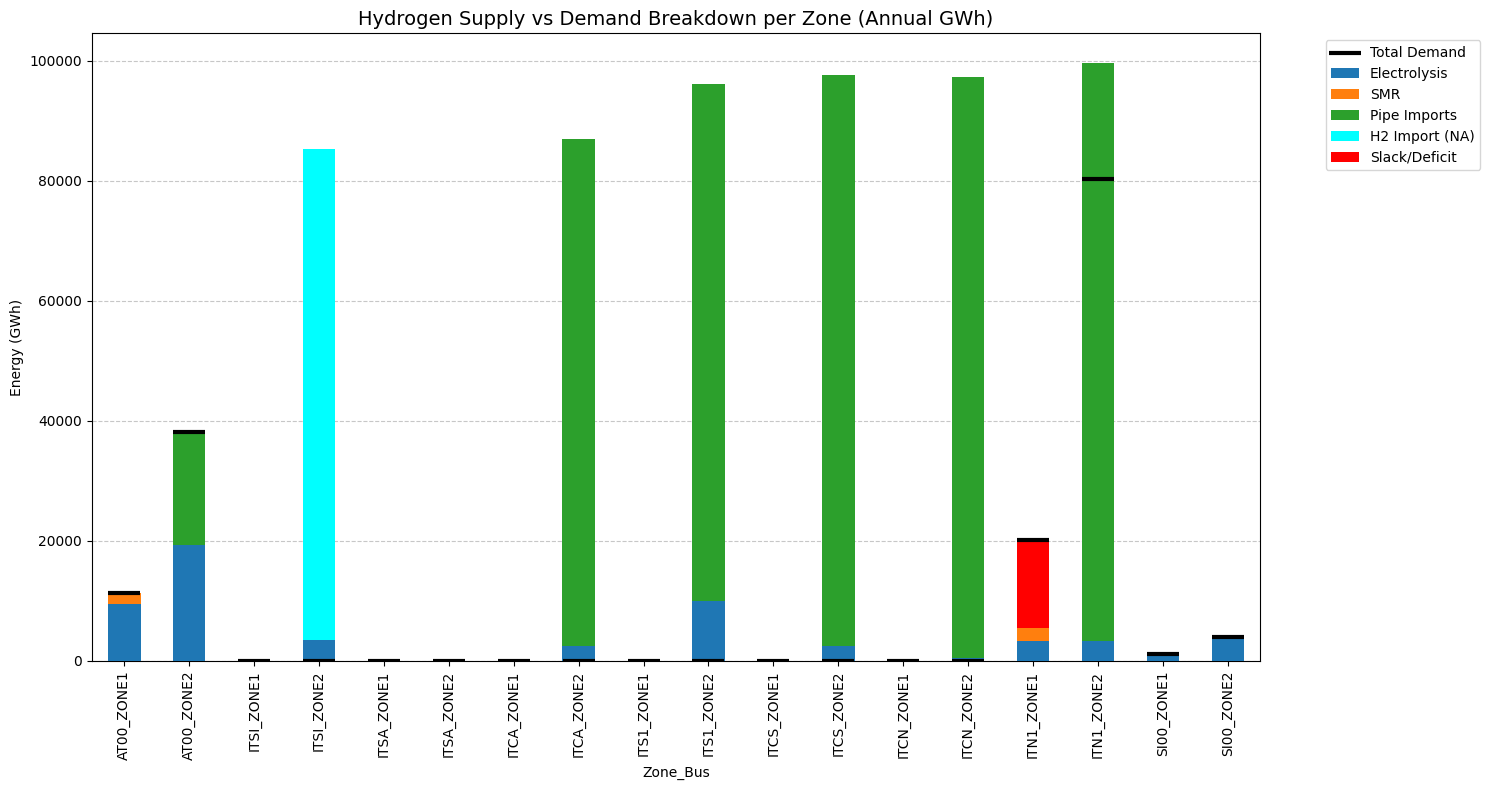

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

h2_balance_data = []

for zone in zones:
    for z_type in ['zone1', 'zone2']:
        bus_name = f"{zone}_h2_{z_type}"
        if bus_name not in n_dual.buses.index: continue

        # 1. Demand (Load)
        loads = n_dual.loads[n_dual.loads.bus == bus_name].index
        total_demand = n_dual.loads_t.p[loads].sum().sum() / 1e3 # GWh

        # 2. Supply Components
        # Electrolysers
        ely_links = n_dual.links[(n_dual.links.bus1 == bus_name) & (n_dual.links.index.str.contains('Electrolyser'))].index
        gen_ely = (n_dual.links_t.p1[ely_links] * -1).sum().sum() / 1e3

        # SMR
        smr_links = n_dual.links[(n_dual.links.bus1 == bus_name) & (n_dual.links.index.str.contains('SMR'))].index
        gen_smr = (n_dual.links_t.p1[smr_links] * -1).sum().sum() / 1e3

        # H2 Imports (North Africa link at ITSI)
        import_gens = n_dual.generators[(n_dual.generators.bus == bus_name) & (n_dual.generators.index.str.contains('Import'))].index
        gen_import = n_dual.generators_t.p[import_gens].sum().sum() / 1e3

        # Slack/Deficit (High-cost slack generators)
        slack_gen = n_dual.generators[(n_dual.generators.bus == bus_name) & (n_dual.generators.index.str.contains('Slack'))].index
        gen_slack = n_dual.generators_t.p[slack_gen].sum().sum() / 1e3

        # Pipeline Flows (Net calculated via links)
        pipe_in = 0
        pipes_as_bus1 = n_dual.links[n_dual.links.bus1 == bus_name].index
        for p in pipes_as_bus1:
            if 'Pipe' in p:
                flow = n_dual.links_t.p1[p] * -1
                pipe_in += flow[flow > 0].sum() / 1e3

        h2_balance_data.append({
            'Zone_Bus': f"{zone}_{z_type.upper()}",
            'Electrolysis': gen_ely,
            'SMR': gen_smr,
            'Pipe Imports': pipe_in,
            'H2 Import (NA)': gen_import,
            'Slack/Deficit': gen_slack,
            'Demand': total_demand
        })

if not h2_balance_data:
    print("ℹ️ No hydrogen bus data found. Check if 'H2' was enabled in input_data.")
else:
    df_h2_balance = pd.DataFrame(h2_balance_data).set_index('Zone_Bus')

    # Filter out columns where all values are 0 to keep the plot clean
    plot_cols = ['Electrolysis', 'SMR', 'Pipe Imports', 'H2 Import (NA)', 'Slack/Deficit']
    colors = {'Electrolysis': '#1f77b4', 'SMR': '#ff7f0e', 'Pipe Imports': '#2ca02c', 'H2 Import (NA)': 'cyan', 'Slack/Deficit': 'red'}

    # Plotting
    fig, ax = plt.subplots(figsize=(15, 8))
    df_h2_balance[plot_cols].plot(kind='bar', stacked=True, ax=ax, zorder=3, color=[colors[c] for c in plot_cols])

    # Overlay Demand markers
    x_pos = range(len(df_h2_balance))
    ax.scatter(x_pos, df_h2_balance['Demand'], color='black', marker='_', s=500, linewidth=3, label='Total Demand', zorder=4)

    plt.title("Hydrogen Supply vs Demand Breakdown per Zone (Annual GWh)", fontsize=14)
    plt.ylabel("Energy (GWh)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [55]:
import pandas as pd

curtailment_stats = []

# Identify all RES generators (standard RES or SRES/DRES)
res_gens = [g for g in n_dual.generators.index if any(x in g for x in ['RES', 'SRES', 'DRES']) and 'slack' not in g.lower()]

for g in res_gens:
    p_nom = n_dual.generators.at[g, 'p_nom']
    p_max_pu = n_dual.generators_t.p_max_pu[g]
    p_dispatched = n_dual.generators_t.p[g]

    potential = (p_max_pu * p_nom).sum()
    actual = p_dispatched.sum()
    curtailment = potential - actual

    curtailment_stats.append({
        'Generator': g,
        'Potential [GWh]': potential / 1e3,
        'Actual [GWh]': actual / 1e3,
        'Curtailed [GWh]': curtailment / 1e3,
        'Curtailment %': (curtailment / potential * 100) if potential > 0 else 0
    })

df_curtailment = pd.DataFrame(curtailment_stats).set_index('Generator')
display(df_curtailment.round(2))

total_curtailment_percent = (df_curtailment['Curtailed [GWh]'].sum() / df_curtailment['Potential [GWh]'].sum() * 100)
print(f"\nOverall Portfolio Curtailment: {total_curtailment_percent:.2f}%")

,Potential [GWh],Actual [GWh],Curtailed [GWh],Curtailment %
Generator,,,,
AT00_SRES_plant,56048.66,56048.66,0.00,0.00
AT00_DRES_plant,56048.66,28427.61,27621.05,49.28
ITSI_SRES_plant,21891.89,21196.96,694.93,3.17
ITSI_DRES_plant,21891.89,5021.17,16870.72,77.06
ITSA_SRES_plant,15297.55,14865.12,432.43,2.83
ITSA_DRES_plant,15297.55,0.00,15297.55,100.00
ITCA_SRES_plant,10702.31,10647.44,54.87,0.51
ITCA_DRES_plant,10702.31,3757.56,6944.75,64.89
ITS1_SRES_plant,35738.84,35733.93,4.90,0.01



Overall Portfolio Curtailment: 35.86%


In [56]:
import matplotlib.pyplot as plt

if not deficits.empty:
    # 1. Summarize Deficits by Zone and Carrier
    deficit_df = deficits.reset_index()
    deficit_df.columns = ['component', 'GWh']
    deficit_df['zone'] = deficit_df['component'].str.split('_').str[0]
    deficit_df['carrier'] = deficit_df['component'].str.split('_').str[1]

    # Fix: Aggregate duplicates (e.g., h2_zone1 and h2_zone2) before pivoting
    zonal_deficits_agg = deficit_df.groupby(['zone', 'carrier'])['GWh'].sum().reset_index()

    # Pivot for a clean overview
    zonal_deficits = zonal_deficits_agg.pivot(index='zone', columns='carrier', values='GWh').fillna(0)
    print("Supply Deficits per Zone (GWh/year):")
    display(zonal_deficits)

    # 2. Visualize the Deficits
    zonal_deficits.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title("Energy Supply Deficits (Slack Generator Usage) by Zone")
    plt.ylabel("Energy Shortfall (GWh)")
    plt.xlabel("Italian Bidding Zone")
    plt.legend(title="Carrier", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No energy supply deficits to plot! The model solved perfectly without slack usage.")


✅ No energy supply deficits to plot! The model solved perfectly without slack usage.


Annual Hydrogen Slack Usage (GWh):


Zone_Type,Z1,Z2
Zone,,
AT00,0.00,0.0
ITCA,0.00,0.0
ITCN,0.00,0.0
ITCS,0.00,0.0
ITN1,14645.79,0.0
ITS1,0.00,0.0
ITSA,0.00,0.0
ITSI,0.00,0.0
SI00,0.00,0.0


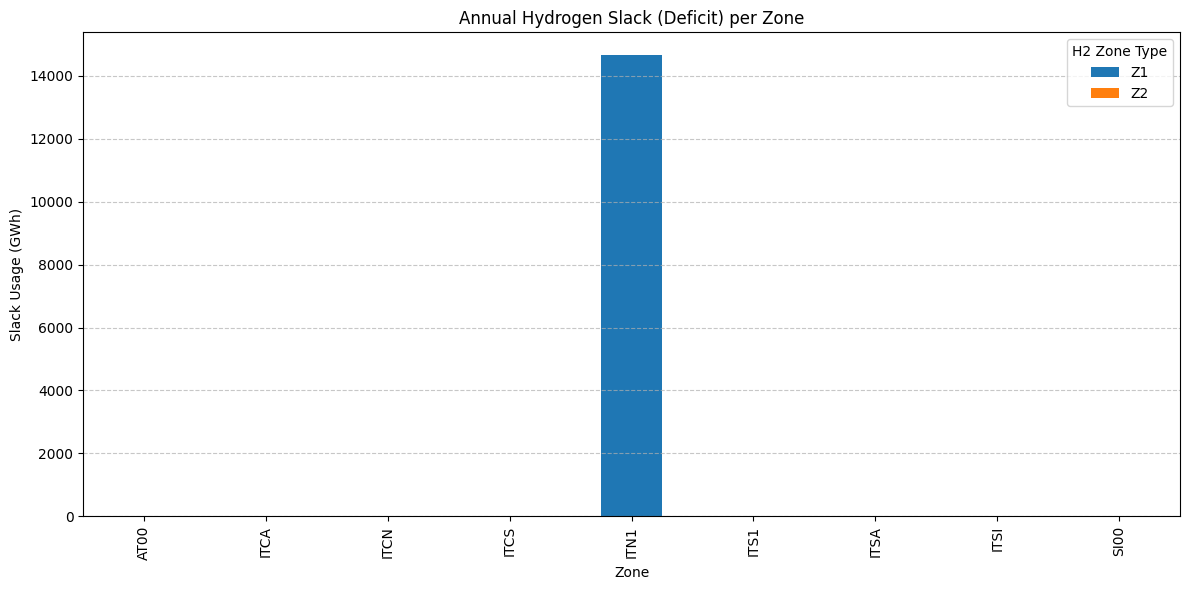

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract all slack generators related to H2
h2_slack_cols = [c for c in n_dual.generators.index if 'H2_Slack' in c]

if h2_slack_cols:
    # Sum the slack usage over the year (MWh -> GWh)
    h2_slack_usage = n_dual.generators_t.p[h2_slack_cols].sum() / 1e3

    slack_data = []
    for col in h2_slack_cols:
        # Example col name: 'AT00_H2_Slack_Z1'
        parts = col.split('_')
        zone = parts[0]
        z_type = parts[-1] # Z1 or Z2
        val = h2_slack_usage[col]
        slack_data.append({'Zone': zone, 'Zone_Type': z_type, 'Slack_GWh': val})

    df_h2_slack = pd.DataFrame(slack_data)

    # Pivot the table for better view: Zones as index, Z1/Z2 as columns
    slack_pivot = df_h2_slack.pivot(index='Zone', columns='Zone_Type', values='Slack_GWh').fillna(0)

    print("Annual Hydrogen Slack Usage (GWh):")
    display(slack_pivot.round(2))

    # Plotting
    plt.figure(figsize=(12, 6))
    slack_pivot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())
    plt.title("Annual Hydrogen Slack (Deficit) per Zone")
    plt.ylabel("Slack Usage (GWh)")
    plt.xlabel("Zone")
    plt.legend(title="H2 Zone Type")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No H2 Slack generators found in the network.")


In [58]:
import pandas as pd
import matplotlib.pyplot as plt

zone = 'AT00'

# Dual Model Balance
demand = n_dual.loads_t.p[f'{zone}_elec_demand']
slack = n_dual.generators_t.p[f'{zone}_electricity_market_slack']
res_gen = n_dual.links_t.p1[f'{zone}_SRES_to_grid'] * -1 if f'{zone}_SRES_to_grid' in n_dual.links.index else pd.Series(0, index=n_dual.snapshots)
nuc_gen = n_dual.generators_t.p[f'{zone}_Nuclear_Plant'] if f'{zone}_Nuclear_Plant' in n_dual.generators.index else pd.Series(0, index=n_dual.snapshots)
ccgt_gen = n_dual.links_t.p1[f'{zone}_CCGT_Plant'] * -1 if f'{zone}_CCGT_Plant' in n_dual.links.index else pd.Series(0, index=n_dual.snapshots)

# Storage Dual
su_n = n_dual.storage_units[n_dual.storage_units.bus == f'{zone}_electricity_market'].index
sto_dis = n_dual.storage_units_t.p_dispatch[su_n].sum(axis=1) if not su_n.empty else pd.Series(0, index=n_dual.snapshots)

# Identify hours where slack is active
slack_hours = slack[slack > 1].index

if not slack_hours.empty:
    print(f"\nSlack generator is active in {len(slack_hours)} hours for AT00 in the dual model.")

    # Display detailed balance for a few of these hours
    diagnostics = pd.DataFrame({
        'Demand': demand,
        'RES Gen': res_gen,
        'Nuclear': nuc_gen,
        'CCGT': ccgt_gen,
        'Storage Dis': sto_dis,
        'Slack (Deficit)': slack
    }).loc[slack_hours]

    display(diagnostics.head(10))

    # Plot the first 72 hours of slack to see the context
    plot_hours = slack_hours[:72] if len(slack_hours) > 72 else slack_hours

    fig, ax = plt.subplots(figsize=(14, 6))
    diagnostics.loc[plot_hours, ['RES Gen', 'Nuclear', 'CCGT', 'Storage Dis', 'Slack (Deficit)']].plot(kind='area', stacked=True, ax=ax)
    ax.plot(plot_hours, diagnostics.loc[plot_hours, 'Demand'], color='red', label='Demand', linewidth=2)
    plt.title('AT00 Dual Model Balance during Slack Hours')
    plt.ylabel('MW')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No significant slack usage found in AT00 dual model.")

No significant slack usage found in AT00 dual model.


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Safely handle the case where deficit_df might not be defined
if 'deficit_df' not in locals():
    slack_df = pd.DataFrame()
else:
    # Prepare data for plotting
    slack_df = deficit_df.copy()

if slack_df.empty:
    print("✅ No energy supply deficits to plot! The model solved perfectly without slack usage.")
else:
    # Clean up carrier names for the legend
    slack_df['carrier'] = slack_df['carrier'].replace({
        'elec': 'Electricity',
        'h2': 'Hydrogen',
        'sng': 'SNG',
        'diesel': 'e-Diesel',
        'kerosene': 'e-Kerosene'
    })

    # Create a faceted bar chart to see each carrier clearly
    g = sns.catplot(
        data=slack_df,
        kind="bar",
        x="zone",
        y="GWh",
        hue="carrier",
        col="carrier",
        col_wrap=3,
        height=4,
        aspect=1.2,
        sharey=False, # Different scales because SNG/Fuel demands are huge compared to elec
        palette="viridis"
    )

    g.set_titles("{col_name} Deficit")
    g.set_axis_labels("Zone", "Shortfall (GWh)")
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Energy Supply Deficits by Carrier and Zone (Annual GWh)', fontsize=16)
    plt.show()


✅ No energy supply deficits to plot! The model solved perfectly without slack usage.


### NTC electricity and hydrogen

In [61]:
import pandas as pd

# 1. Electricity NTC Description
print("--- Electricity Interconnections ---")
elec_summary = NTC_elec_df.copy()
elec_summary['Description'] = elec_summary.apply(lambda x: f"Power flow from {x['zone 1']} to {x['zone 2']}", axis=1)
elec_summary = elec_summary[['Description', 'capacity, MW', 'losses']]
display(elec_summary)

# 2. Hydrogen NTC Description
print("\n--- Hydrogen Interconnections ---")
if 'NTC_H2_df' in locals():
    h2_summary = []
    for _, row in NTC_H2_df.iterrows():
        # Forward direction
        h2_summary.append({
            'Description': f"H2 pipeline from {row['zone 1']} to {row['zone 2']}",
            'Capacity (MW)': row['capacity_MW'],
            'Efficiency': row['efficiency']
        })
        # Reverse direction (if capacity exists)
        if row['capacity_rev_MW'] > 0:
            h2_summary.append({
                'Description': f"H2 pipeline from {row['zone 2']} to {row['zone 1']}",
                'Capacity (MW)': row['capacity_rev_MW'],
                'Efficiency': row['efficiency']
            })

    h2_desc_df = pd.DataFrame(h2_summary)
    display(h2_desc_df)
else:
    print("No Hydrogen NTC data found.")

--- Electricity Interconnections ---


,Description,"capacity, MW",losses
0,Power flow from AT00 to ITN1,875.0,0.95
1,Power flow from ITN1 to AT00,695.0,0.95
2,Power flow from AT00 to SI00,950.0,0.95
3,Power flow from SI00 to AT00,950.0,0.95
4,Power flow from ITCN to ITCS,4650.0,0.95
5,Power flow from ITCS to ITCN,5350.0,0.95
6,Power flow from ITCN to ITN1,4500.0,0.95
7,Power flow from ITN1 to ITCN,5300.0,0.95
8,Power flow from ITCS to ITS1,3100.0,0.95
9,Power flow from ITS1 to ITCS,5700.0,0.95



--- Hydrogen Interconnections ---


,Description,Capacity (MW),Efficiency
0,H2 pipeline from AT00 to ITN1,5250.0,0.98
1,H2 pipeline from ITN1 to AT00,7000.0,0.98
2,H2 pipeline from ITSI to ITCA,25000.0,0.99
3,H2 pipeline from ITCA to ITSI,25000.0,0.99
4,H2 pipeline from ITCA to ITS1,25000.0,0.99
5,H2 pipeline from ITS1 to ITCA,25000.0,0.99
6,H2 pipeline from ITS1 to ITCS,25000.0,0.99
7,H2 pipeline from ITCS to ITS1,25000.0,0.99
8,H2 pipeline from ITCS to ITCN,25000.0,0.99
9,H2 pipeline from ITCN to ITCS,25000.0,0.99


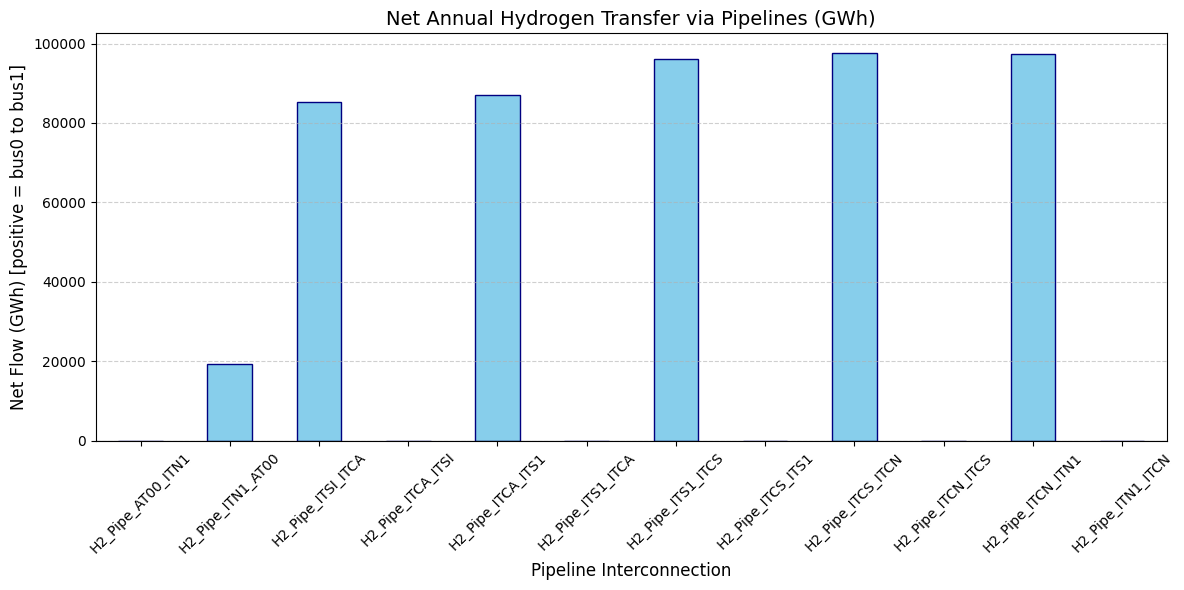

In [62]:
import matplotlib.pyplot as plt

# Filter for hydrogen pipeline links
h2_pipe_links = n_dual.links[n_dual.links.index.str.contains('H2_Pipe')].index

if not h2_pipe_links.empty:
    # Calculate the total net flow (GWh) for each pipeline
    # Note: p0 > 0 means flow from bus0 to bus1
    h2_flows = n_dual.links_t.p0[h2_pipe_links].sum() / 1e3  # Convert to GWh

    # Plotting
    plt.figure(figsize=(12, 6))
    h2_flows.plot(kind='bar', color='skyblue', edgecolor='navy')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title("Net Annual Hydrogen Transfer via Pipelines (GWh)", fontsize=14)
    plt.ylabel("Net Flow (GWh) [positive = bus0 to bus1]", fontsize=12)
    plt.xlabel("Pipeline Interconnection", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No hydrogen pipeline links found in the network to visualize.")

### Pricing, Demand and Production

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Hydrogen Balance per Zone
h2_bus_stats = []
for zone in zones:
    for bus_suffix in ['zone1', 'zone2']:
        bus_name = f"{zone}_h2_{bus_suffix}"
        if bus_name in n_dual.buses_t.marginal_price.columns:
            price = n_dual.buses_t.marginal_price[bus_name].mean()
            production = n_dual.links_t.p1[[c for c in n_dual.links_t.p1.columns if bus_name == n_dual.links.at[c, 'bus1']]].sum().sum() * -1
            demand = n_dual.loads_t.p[[c for c in n_dual.loads_t.p.columns if bus_name == n_dual.loads.at[c, 'bus']]].sum().sum()
            h2_bus_stats.append({'Bus': bus_name, 'Avg Price': price, 'Total Production (MWh)': production, 'Total Demand (MWh)': demand})

h2_diagnostic_df = pd.DataFrame(h2_bus_stats)
print("Hydrogen Bus Diagnostics:")
display(h2_diagnostic_df)

# 2. Check Synthesis Link Utilization (Fixed at 100 MW)
synth_links = n_dual.links[n_dual.links.index.str.contains('H2_to_')].index
if not synth_links.empty:
    synth_stats = pd.DataFrame({
        'Fixed Capacity (MW)': n_dual.links.loc[synth_links, 'p_nom'],
        'Total Output (MWh)': n_dual.links_t.p1[synth_links].sum() * -1,
        'Capacity Factor': (n_dual.links_t.p1[synth_links].sum() * -1) / (n_dual.links.loc[synth_links, 'p_nom'] * len(n_dual.snapshots))
    })
    print("\nSynthesis Link Performance (100 MW fixed):")
    display(synth_stats)
else:
    print("No synthesis links found.")

Hydrogen Bus Diagnostics:


,Bus,Avg Price,Total Production (MWh),Total Demand (MWh)
0,AT00_h2_zone1,82.261328,1.131898e+07,1.126744e+07
1,AT00_h2_zone2,28.729458,3.821249e+07,3.821249e+07
2,ITSI_h2_zone1,0.000000,-0.000000e+00,0.000000e+00
3,ITSI_h2_zone2,26.775000,3.427502e+06,0.000000e+00
4,ITSA_h2_zone1,0.000000,-0.000000e+00,0.000000e+00
5,ITSA_h2_zone2,0.000000,-0.000000e+00,0.000000e+00
6,ITCA_h2_zone1,0.000000,-0.000000e+00,0.000000e+00
7,ITCA_h2_zone2,27.045455,8.696365e+07,0.000000e+00
8,ITS1_h2_zone1,0.000000,-0.000000e+00,0.000000e+00
9,ITS1_h2_zone2,27.318641,9.608527e+07,0.000000e+00


No synthesis links found.


In [64]:
import pandas as pd

# Extract marginal prices (LMPs) from the dual network
# Electricity bus: {zone}_electricity_market
# Hydrogen Zone 1: {zone}_h2_zone1
# Hydrogen Zone 2: {zone}_h2_zone2

price_summary = []

for z in zones:
    row = {'Zone': z}

    # Electricity Price
    elec_bus = f"{z}_electricity_market"
    if elec_bus in n_dual.buses_t.marginal_price.columns:
        row['Elec Price [€/MWh]'] = n_dual.buses_t.marginal_price[elec_bus].mean()

    # H2 Zone 1 Price
    h2_z1 = f"{z}_h2_zone1"
    if h2_z1 in n_dual.buses_t.marginal_price.columns:
        row['H2 Z1 Price [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z1].mean()

    # H2 Zone 2 Price
    h2_z2 = f"{z}_h2_zone2"
    if h2_z2 in n_dual.buses_t.marginal_price.columns:
        row['H2 Z2 Price [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z2].mean()

    price_summary.append(row)

df_zonal_prices = pd.DataFrame(price_summary).set_index('Zone')

print("Average Marginal Prices per Bidding Zone (Annual Mean):")
display(df_zonal_prices.round(2))

Average Marginal Prices per Bidding Zone (Annual Mean):


,Elec Price [€/MWh],H2 Z1 Price [€/MWh],H2 Z2 Price [€/MWh]
Zone,,,
AT00,55.94,82.26,28.73
ITSI,47.41,0.00,26.77
ITSA,50.19,0.00,0.00
ITCA,52.31,0.00,27.05
ITS1,55.06,0.00,27.32
ITCS,63.53,0.00,27.59
ITCN,66.94,0.00,27.87
ITN1,71.00,1000.00,28.15
SI00,69.03,101.52,79.86


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check North African Import Utilization (Average Hourly %)
h2_import_gens = [g for g in n_dual.generators.index if 'H2_Import' in g]
if h2_import_gens:
    # Correct calculation: Mean power output / Nominal capacity
    import_p_mean = n_dual.generators_t.p[h2_import_gens].mean()
    import_cap = n_dual.generators.loc[h2_import_gens, 'p_nom']
    import_util = (import_p_mean / import_cap) * 100

    print("--- North African H2 Import Utilization ---")
    display(import_util.to_frame('Avg Hourly Utilization (%)').round(2))
else:
    print("No H2 Import generators found.")

# 2. Check Italian H2 Backbone Pipeline Flows vs Capacity
h2_pipes = [l for l in n_dual.links.index if 'H2_Pipe' in l and any(z in l for z in ['ITSI', 'ITCA', 'ITS1', 'ITCS', 'ITCN', 'ITN1'])]
if h2_pipes:
    pipe_flows = n_dual.links_t.p0[h2_pipes].abs().max()
    pipe_caps = n_dual.links.loc[h2_pipes, 'p_nom']
    pipe_util = (pipe_flows / pipe_caps) * 100

    backbone_stats = pd.DataFrame({
        'Max Hourly Flow (MW)': pipe_flows,
        'Capacity (MW)': pipe_caps,
        'Peak Utilization (%)': pipe_util
    })
    print("\n--- Italian H2 Backbone Utilization ---")
    display(backbone_stats.round(2))
else:
    print("No Italian H2 backbone links found.")

--- North African H2 Import Utilization ---


,Avg Hourly Utilization (%)
name,
ITSI_H2_Import,42.01



--- Italian H2 Backbone Utilization ---


,Max Hourly Flow (MW),Capacity (MW),Peak Utilization (%)
name,,,
H2_Pipe_AT00_ITN1,0.00,5250.0,0.00
H2_Pipe_ITN1_AT00,5560.99,7000.0,79.44
H2_Pipe_ITSI_ITCA,22245.97,25000.0,88.98
H2_Pipe_ITCA_ITSI,0.00,25000.0,0.00
H2_Pipe_ITCA_ITS1,22148.97,25000.0,88.60
H2_Pipe_ITS1_ITCA,0.00,25000.0,0.00
H2_Pipe_ITS1_ITCS,22291.96,25000.0,89.17
H2_Pipe_ITCS_ITS1,0.00,25000.0,0.00
H2_Pipe_ITCS_ITCN,22360.83,25000.0,89.44


Average Marginal Prices per Zone:


,Electricity Market [€/MWh],H2 Zone 1 [€/MWh],H2 Zone 2 [€/MWh]
Zone,,,
AT00,55.94,82.26,28.73
ITSI,47.41,0.00,26.77
ITSA,50.19,0.00,0.00
ITCA,52.31,0.00,27.05
ITS1,55.06,0.00,27.32
ITCS,63.53,0.00,27.59
ITCN,66.94,0.00,27.87
ITN1,71.00,1000.00,28.15
SI00,69.03,101.52,79.86


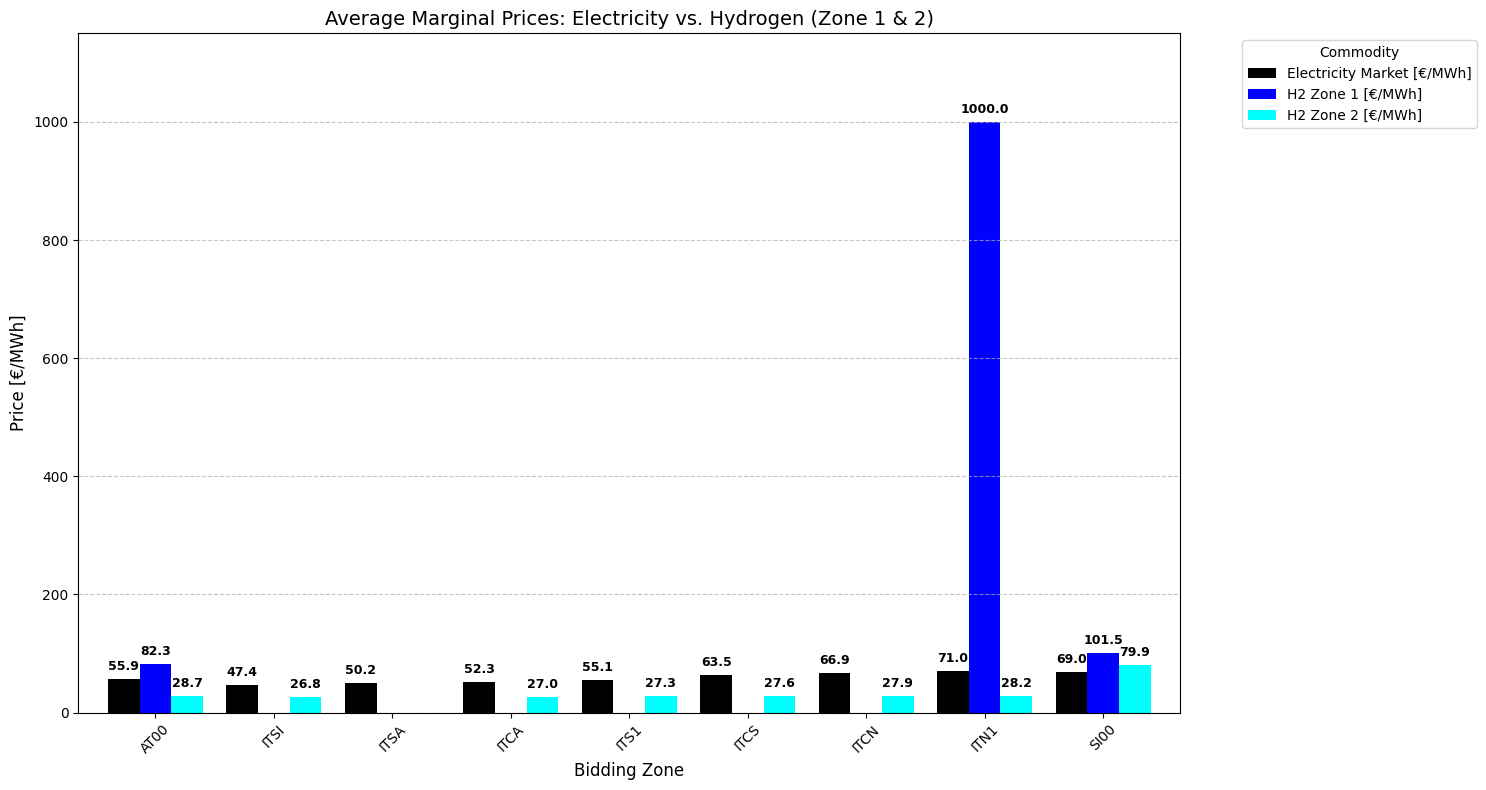

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract Marginal Prices (Marginal Costs) for Electricity and Hydrogen
price_data = []

for z in zones:
    z_prices = {'Zone': z}

    # Electricity Market Price
    elec_bus = f"{z}_electricity_market"
    if elec_bus in n_dual.buses_t.marginal_price.columns:
        z_prices['Electricity Market [€/MWh]'] = n_dual.buses_t.marginal_price[elec_bus].mean()

    # Hydrogen Zone 1 Price
    h2_z1_bus = f"{z}_h2_zone1"
    if h2_z1_bus in n_dual.buses_t.marginal_price.columns:
        z_prices['H2 Zone 1 [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z1_bus].mean()

    # Hydrogen Zone 2 Price
    h2_z2_bus = f"{z}_h2_zone2"
    if h2_z2_bus in n_dual.buses_t.marginal_price.columns:
        z_prices['H2 Zone 2 [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z2_bus].mean()

    price_data.append(z_prices)

df_prices = pd.DataFrame(price_data).set_index('Zone')

print("Average Marginal Prices per Zone:")
display(df_prices.round(2))

# 2. Visualization with Requested Colors
# Black for Electricity, Blue for H2 Zone 1, Cyan for H2 Zone 2
custom_colors = ['#000000', '#0000FF', '#00FFFF']

fig, ax = plt.subplots(figsize=(15, 8))
df_prices.plot(kind='bar', ax=ax, width=0.8, color=custom_colors)

# Add numbers on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9,
                    fontweight='bold')

plt.title("Average Marginal Prices: Electricity vs. Hydrogen (Zone 1 & 2)", fontsize=14)
plt.ylabel("Price [€/MWh]", fontsize=12)
plt.xlabel("Bidding Zone", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, df_prices.max().max() * 1.15)  # Make space for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Commodity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Technologies - Electrolysers and SMR

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Pipeline Congestion (Shadow Prices / Dual Values)
# Note: mu_upper represents the marginal value of increasing capacity
h2_links = [l for l in n_dual.links.index if 'H2_Pipe' in l]
print("--- H2 Pipeline Congestion Analysis (Mean Shadow Price) ---")

if h2_links:
    # Safety check: mu_upper might not exist if the solver didn't provide duals or if links weren't constrained
    if hasattr(n_dual.links_t, 'mu_upper') and not n_dual.links_t.mu_upper.empty:
        # Filter for links present in the shadow price table
        available_mu = [l for l in h2_links if l in n_dual.links_t.mu_upper.columns]
        if available_mu:
            pipeline_shadow_prices = n_dual.links_t.mu_upper[available_mu].mean().sort_values(ascending=False)
            display(pipeline_shadow_prices.head(10).to_frame('Mean Shadow Price [€/MW]'))
        else:
            print("No shadow price data found for the specified H2 pipelines.")
    else:
        print("Shadow prices (mu_upper) are not available in the network results.")
else:
    print("No H2 pipelines found in the network.")

# 2. Check Electrolyzer Utilization
print("\n--- Electrolyzer Capacity Factor (%) ---")
ely_links = [l for l in n_dual.links.index if 'Electrolyser' in l]
if ely_links:
    # p0 is the power intake (MW). Capacity Factor = Mean Flow / Nominal Capacity
    # We use .abs() to ensure we get magnitude regardless of sign convention
    ely_p0 = n_dual.links_t.p0[ely_links].abs()
    ely_caps = n_dual.links.loc[ely_links, 'p_nom']

    # Avoid division by zero if p_nom is 0
    ely_usage = (ely_p0.mean() / ely_caps.replace(0, float('inf')) * 100).sort_values(ascending=False)
    display(ely_usage.to_frame('Capacity Factor (%)').round(2))
else:
    print("No electrolyzer links found.")

# 3. Check Slack Generator Activation
h2_slacks = [g for g in n_dual.generators.index if 'H2_Slack' in g]
if h2_slacks:
    slack_sum = n_dual.generators_t.p[h2_slacks].sum().sort_values(ascending=False)
    active_slacks = slack_sum[slack_sum > 1e-3]
    if not active_slacks.empty:
        print("\n--- Total Annual H2 Slack Energy Usage (MWh) ---")
        display(active_slacks.to_frame('Annual Slack [MWh]'))
    else:
        print("\n✅ No H2 slack activation detected (Demand fully met).")

--- H2 Pipeline Congestion Analysis (Mean Shadow Price) ---
Shadow prices (mu_upper) are not available in the network results.

--- Electrolyzer Capacity Factor (%) ---


,Capacity Factor (%)
name,
ITN1_DRES_Electrolyser,100.00
ITN1_SRES_Electrolyser,100.00
ITCN_DRES_Electrolyser,100.00
ITCS_DRES_Electrolyser,99.69
AT00_DRES_Electrolyser,94.36
ITCA_DRES_Electrolyser,89.61
ITSI_DRES_Electrolyser,89.15
ITS1_DRES_Electrolyser,87.22
SI00_DRES_Electrolyser,58.49



--- Total Annual H2 Slack Energy Usage (MWh) ---


,Annual Slack [MWh]
name,
ITN1_H2_Slack_Z1,1.464579e+07


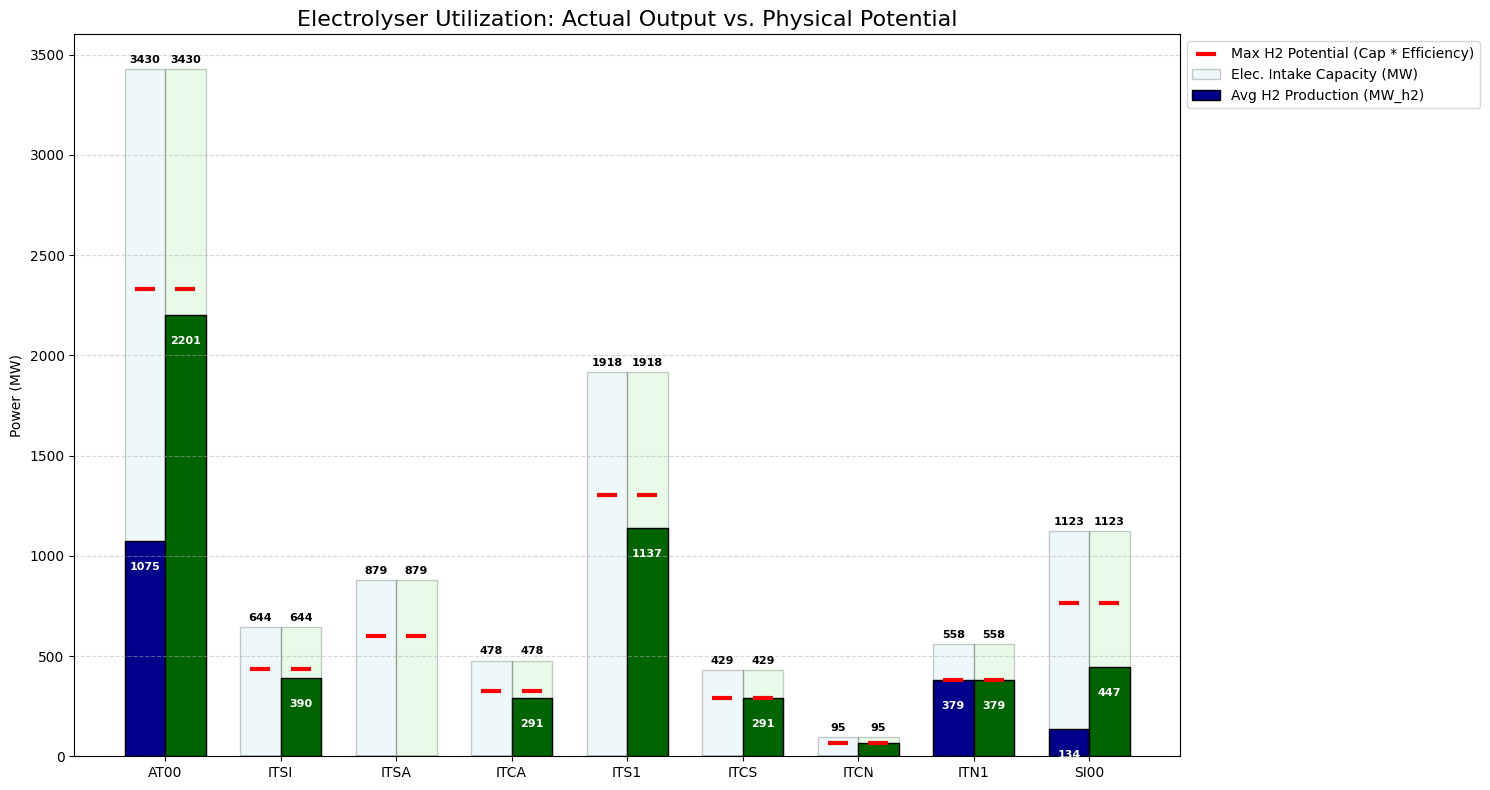

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data for Electrolyser capacity and usage
ely_stats = []
zones_list = list(model_data.keys())

for z in zones_list:
    z_data = model_data.get(z, {})
    eff = z_data.get('elec_efficiency', 0.68)

    # Capacities (MW electrical)
    sres_cap = z_data.get('SRES_electrolyser', 0)
    dres_cap = z_data.get('DRES_electrolyser', 0)

    # H2 Output Potential (MW H2)
    sres_pot = sres_cap * eff
    dres_pot = dres_cap * eff

    # Usage (Average MW H2 produced)
    sres_link = f"{z}_SRES_Electrolyser"
    sres_usage_mw = (n_dual.links_t.p1[sres_link] * -1).mean() if sres_link in n_dual.links_t.p1.columns else 0

    dres_link = f"{z}_DRES_Electrolyser"
    dres_usage_mw = (n_dual.links_t.p1[dres_link] * -1).mean() if dres_link in n_dual.links_t.p1.columns else 0

    ely_stats.append({
        'Zone': z,
        'SRES_Cap': sres_cap,
        'SRES_Pot': sres_pot,
        'SRES_Usage': sres_usage_mw,
        'DRES_Cap': dres_cap,
        'DRES_Pot': dres_pot,
        'DRES_Usage': dres_usage_mw
    })

df_ely = pd.DataFrame(ely_stats).set_index('Zone')

# 2. Plotting
fig, ax = plt.subplots(figsize=(15, 8))
x = np.arange(len(df_ely.index))
width = 0.35

# Background: Electrical Capacity
rects1_bg = ax.bar(x - width/2, df_ely['SRES_Cap'], width, label='Elec. Intake Capacity (MW)', color='#add8e6', edgecolor='black', alpha=0.2)
rects2_bg = ax.bar(x + width/2, df_ely['DRES_Cap'], width, color='#90ee90', edgecolor='black', alpha=0.2)

# Foreground: Average H2 Production
rects1_fg = ax.bar(x - width/2, df_ely['SRES_Usage'], width, label='Avg H2 Production (MW_h2)', color='#00008b', edgecolor='black')
rects2_fg = ax.bar(x + width/2, df_ely['DRES_Usage'], width, color='#006400', edgecolor='black')

# Markers: Max H2 Potential
ax.scatter(x - width/2, df_ely['SRES_Pot'], color='red', marker='_', s=200, linewidth=3, label='Max H2 Potential (Cap * Efficiency)', zorder=5)
ax.scatter(x + width/2, df_ely['DRES_Pot'], color='red', marker='_', s=200, linewidth=3, zorder=5)

# Helper function to add labels
def autolabel(rects, is_usage=False):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.0f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if not is_usage else -15),  # offset text
                        textcoords="offset points",
                        ha='center', va='bottom' if not is_usage else 'top',
                        fontsize=8, fontweight='bold', color='black' if not is_usage else 'white')

# Add numbers to the foreground (usage) and background (capacity)
autolabel(rects1_bg)
autolabel(rects2_bg)
autolabel(rects1_fg, is_usage=True)
autolabel(rects2_fg, is_usage=True)

# Formatting
ax.set_title('Electrolyser Utilization: Actual Output vs. Physical Potential', fontsize=16)
ax.set_ylabel('Power (MW)')
ax.set_xticks(x)
ax.set_xticklabels(df_ely.index)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Exporting PyPSA Results
There are two main ways to save your results:
1. **Full Network Export**: Saves everything (buses, links, generators, and all time-series results) to a folder.
2. **Selective Export**: Saving specific DataFrames (like prices or power flow) to Excel or CSV.

In [68]:
prefix_results = f"FLEX_{input_data['FLEX']}_NTC_{input_data['NTC']}_H2_{input_data['H2']}_Syn_{input_data['Synthetic_fuels']}"

In [69]:
prefix_results

'FLEX_True_NTC_True_H2_True_Syn_False'

In [70]:
import os

# Create a results directory
# FIXED: Added missing quotes for f-string formatting
results_path = os.path.join(PROJECT_DIR, 'results', project_name, f"{input_data['scenario']}", f"{input_data['year']}")
if not os.path.exists(results_path):
    os.makedirs(results_path)

# 1. Export the entire network (Standard PyPSA format)
n_dual.export_to_csv_folder(os.path.join(results_path, f'{prefix_results}_full_network_export'))

print(f"✅ Results saved to {results_path}")

✅ Results saved to /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/results/Italy/GA/2040


In [71]:
# Access time-series results (dispatching) and inputs from the network

# Power output of generators (p)
gen_p = n_dual.generators_t.p
# Power flow on links at bus0 (p0) and bus1 (p1)
link_p0 = n_dual.links_t.p0
link_p1 = n_dual.links_t.p1
# Power dispatched from storage units (p_dispatch) and stored into them (p_store)
storage_p_dispatch = n_dual.storage_units_t.p_dispatch
storage_p_store = n_dual.storage_units_t.p_store
# Load demand (p_set)
load_p = n_dual.loads_t.p
# Marginal prices at buses
bus_marginal_price = n_dual.buses_t.marginal_price

# Combine all time-series data into a single DataFrame
# Use .add_prefix() to distinguish columns if names might overlap
all_time_series_data = pd.concat(
    [
        gen_p.add_prefix('gen_p_'),
        link_p0.add_prefix('link_p0_'),
        link_p1.add_prefix('link_p1_'),
        storage_p_dispatch.add_prefix('storage_p_dispatch_'),
        storage_p_store.add_prefix('storage_p_store_'),
        load_p.add_prefix('load_p_'),
        bus_marginal_price.add_prefix('marginal_price_')
    ],
    axis=1
)

# Define the output path for the CSV file
timeseries_results_path = os.path.join(results_path, f'{prefix_results}_time_series_results.csv')

# Save the combined DataFrame to a CSV file
all_time_series_data.to_csv(timeseries_results_path)

print(f"✅ All time-series dispatching results and inputs saved to: {timeseries_results_path}")
print("Shape of the combined DataFrame:", all_time_series_data.shape)
display(all_time_series_data.head(3))

✅ All time-series dispatching results and inputs saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/results/Italy/GA/2040/FLEX_True_NTC_True_H2_True_Syn_False_time_series_results.csv
Shape of the combined DataFrame: (8784, 456)


name,gen_p_Global_Coal_Import,gen_p_AT00_Gas_Source,gen_p_AT00_Nuclear_Plant,gen_p_AT00_SRES_plant,gen_p_AT00_DRES_plant,gen_p_AT00_H2_Slack_Z1,gen_p_AT00_H2_Slack_Z2,gen_p_ITSI_Gas_Source,gen_p_ITSI_SRES_plant,gen_p_ITSI_DRES_plant,...,marginal_price_ITN1_SRES_AC,marginal_price_ITN1_DRES_AC,marginal_price_ITN1_h2_zone1,marginal_price_ITN1_h2_zone2,marginal_price_SI00_electricity_market,marginal_price_SI00_gas_bus,marginal_price_SI00_SRES_AC,marginal_price_SI00_DRES_AC,marginal_price_SI00_h2_zone1,marginal_price_SI00_h2_zone2
snapshot,,,,,,,,,,,,,,,,,,,,,
2040-01-01 00:00:00,945.0,423.35,5000.0,2026.401501,2026.401501,-0.0,-0.0,-0.0,2391.886517,643.665,...,65.636364,4.6,1000.0,28.154869,69.134545,40.0,69.134545,69.134545,101.668449,101.668449
2040-01-01 01:00:00,945.0,423.35,5000.0,2050.310906,2050.310906,-0.0,-0.0,-0.0,1635.431163,643.665,...,65.636364,4.6,1000.0,28.154869,69.090909,40.0,69.090909,69.090909,101.604278,101.604278
2040-01-01 02:00:00,945.0,423.35,5000.0,1991.475544,1991.475544,-0.0,-0.0,-0.0,1434.226100,643.665,...,65.636364,4.6,1000.0,28.154869,69.090909,40.0,69.090909,69.090909,101.604278,101.604278


## Electricity Network Model

In [72]:
# 1. INITIALIZE ENHANCED ELECTRICITY NETWORK
n_elec = pypsa.Network()
n_elec.set_snapshots(RES_profiles.index)

# Carriers
for c in ["AC", "coal", "natural_gas", "hydro", "battery", "nuclear"]:
    n_elec.add("Carrier", c)


# Global market for coal
n_elec.add("Bus", "EU_coal_market", carrier="coal")
n_elec.add("Generator", "Global_Coal_Import", bus="EU_coal_market", p_nom_extendable=True, marginal_cost=25)

# 2. BUILD ZONAL ELECTRICITY NETWORKS WITH FULL CAPACITIES
for zone, z_data in model_data.items():
    elec_bus = f"{zone}_electricity"
    n_elec.add("Bus", elec_bus, carrier="AC")
    n_elec.add("Bus", f"{zone}_gas_bus", carrier="natural_gas")

    # Gas supply
    n_elec.add("Generator", f"{zone}_Gas_Source", bus=f"{zone}_gas_bus", carrier="natural_gas", p_nom_extendable=True, marginal_cost=40)

    # Conventional Plants
    if z_data.get('gas_ccgt', 0) > 0:
        n_elec.add("Link", f"{zone}_CCGT", bus0=f"{zone}_gas_bus", bus1=elec_bus, p_nom=z_data['gas_ccgt'], efficiency=0.55)

    if z_data.get('coal', 0) > 0:
        # Coal Ramping: 12 hours to full capacity -> 1/12 per hour
        n_elec.add("Link", f"{zone}_Coal", bus0="EU_coal_market", bus1=elec_bus, p_nom=z_data['coal'], efficiency=0.40, ramp_limit_up=1/12, ramp_limit_down=1/12)

    if z_data.get('nuclear', 0) > 0:
        # Nuclear Ramping: 48 hours to full capacity -> 1/48 per hour
        n_elec.add("Generator", f"{zone}_Nuclear", bus=elec_bus, carrier="nuclear", p_nom=z_data['nuclear'], marginal_cost=12.0, ramp_limit_up=1/48, ramp_limit_down=1/48)

    # RES Generation
    if 'Nonflex_Total_RES' in z_data:
        n_elec.add("Generator", f"{zone}_RES", bus=elec_bus, carrier="AC", p_nom=1, p_max_pu=z_data['Nonflex_Total_RES'], marginal_cost=4.6)

    # 3. STORAGE ASSETS (Conditional on RES_flex)
    if input_data.get('FLEX', True):
        if zone in capacities:
            caps = capacities[zone]
            if 'Hydro' in caps:
                h = caps['Hydro']
                p_res = h.get('Reservoir - Total turbining capacity (MW)', 0)
                if p_res > 0:
                    n_elec.add("StorageUnit", f"{zone}_HPP_Reservoir", bus=elec_bus, carrier="hydro", p_nom=p_res,
                      max_hours=(h.get('Reservoir - Total reservoir capacity (GWh)', 0)*1e3)/p_res,
                      cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                      p_max_pu=RES_profiles[f"{zone}_Res_Inflow_MW"]/p_res if f"{zone}_Res_Inflow_MW" in RES_profiles.columns else 0)
                p_pond = h.get('Pondage - Total turbining capacity (MW)', 0)
                if p_pond > 0:
                    n_elec.add("StorageUnit", f"{zone}_HPP_Pondage", bus=elec_bus, carrier="hydro", p_nom=p_pond,
                    max_hours=(h.get('Pondage - Total reservoir capacity (GWh)', 0)*1e3)/p_pond,
                    cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                    p_max_pu=RES_profiles[f"{zone}_Pondage_MW"]/p_pond if f"{zone}_Pondage_MW" in RES_profiles.columns else 0)
                p_open = h.get('Pump Storage (open loop, with natural inflows) - Total turbining capacity (MW)', 0)
                if p_open > 0:
                    p_pump = abs(h.get('Pump Storage (open loop, with natural inflows) - Total pumping capacity (MW)', 0))
                    n_elec.add("StorageUnit", f"{zone}_PHS_Open", bus=elec_bus, carrier="hydro", p_nom=p_open, p_max_pu_store=p_pump/p_open,
                    max_hours=(h.get('Pump Storage (open loop, with natural inflows) - Total reservoir capacity (GWh)', 0)*1e3)/p_open,
                      cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)
                p_closed = h.get('Pure Pump Storage (closed loop, no natural inflows) - Total turbining capacity (MW)', 0)
                if p_closed > 0:
                    p_pump_c = abs(h.get('Pure Pump Storage (closed loop, no natural inflows) - Total pumping capacity (MW)', 0))
                    n_elec.add("StorageUnit", f"{zone}_PHS_Closed", bus=elec_bus, carrier="hydro", p_nom=p_closed, p_max_pu_store=p_pump_c/p_closed,
                          max_hours=(h.get('Pure Pump Storage (closed loop, no natural inflows) - Total reservoir capacity (GWh)', 0)*1e3)/p_closed,
                          cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)

            if 'Battery' in caps:
                b = caps['Battery']
                p_bat = b.get('Net maximum capacity - generation perspective \n(MW)', 0)
                if p_bat > 0:
                    n_elec.add("StorageUnit", f"{zone}_Battery", bus=elec_bus, carrier="battery", p_nom=p_bat,
                          p_max_pu_store=abs(b.get('Net maximum capacity - demand perspective \n(MW)', 0))/p_bat,
                          max_hours=b.get('Storage capacity \n(MWh)', 0)/p_bat, cyclic_state_of_charge=True, efficiency_dispatch=0.95, efficiency_store=0.95)

    # 4. LOADS AND SLACKS
    n_elec.add("Load", f"{zone}_demand", bus=elec_bus, p_set=z_data['El_market'])
    n_elec.add("Generator", f"{zone}_elec_slack", bus=elec_bus, p_nom_extendable=True, marginal_cost=1e6, carrier="slack")

# 5. CROSS-BORDER LINKS (Conditional on NTC_included)
if input_data.get('NTC', True):
    for index, row in NTC_elec_df.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap = row['capacity, MW']
        eff = row['losses']
        n_elec.add("Link", f"Elec_Link_{z1}_{z2}", bus0=f"{z1}_electricity", bus1=f"{z2}_electricity", p_nom=cap, efficiency=eff, bidirectional=False)

n_elec.sanitize()
print("Optimizing Improved Electricity-Only Network with corrected storage and ramping constraints...")
status = n_elec.optimize(solver_name='highs')
print(f"Status: {status}")

Optimizing Improved Electricity-Only Network with corrected storage and ramping constraints...


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 117.83it/s]


Status: ('ok', 'optimal')


In [73]:
# Count the total number of variables in the optimized model
# In linopy, we iterate through the dataset keys
total_vars = sum(n_elec.model.variables[v].size for v in n_elec.model.variables)
print(f"The total number of variables in the optimized model is: {total_vars:,}")

# Break down variables by type for better detail
print("\nVariable counts by component:")
for name in n_elec.model.variables:
    size = n_elec.model.variables[name].size
    if size > 0:
        print(f"- {name}: {size:,}")

The total number of variables in the optimized model is: 1,343,971

Variable counts by component:
- Generator-p_nom: 19
- Generator-p: 263,520
- Link-p: 289,872
- StorageUnit-p_dispatch: 263,520
- StorageUnit-p_store: 263,520
- StorageUnit-state_of_charge: 263,520


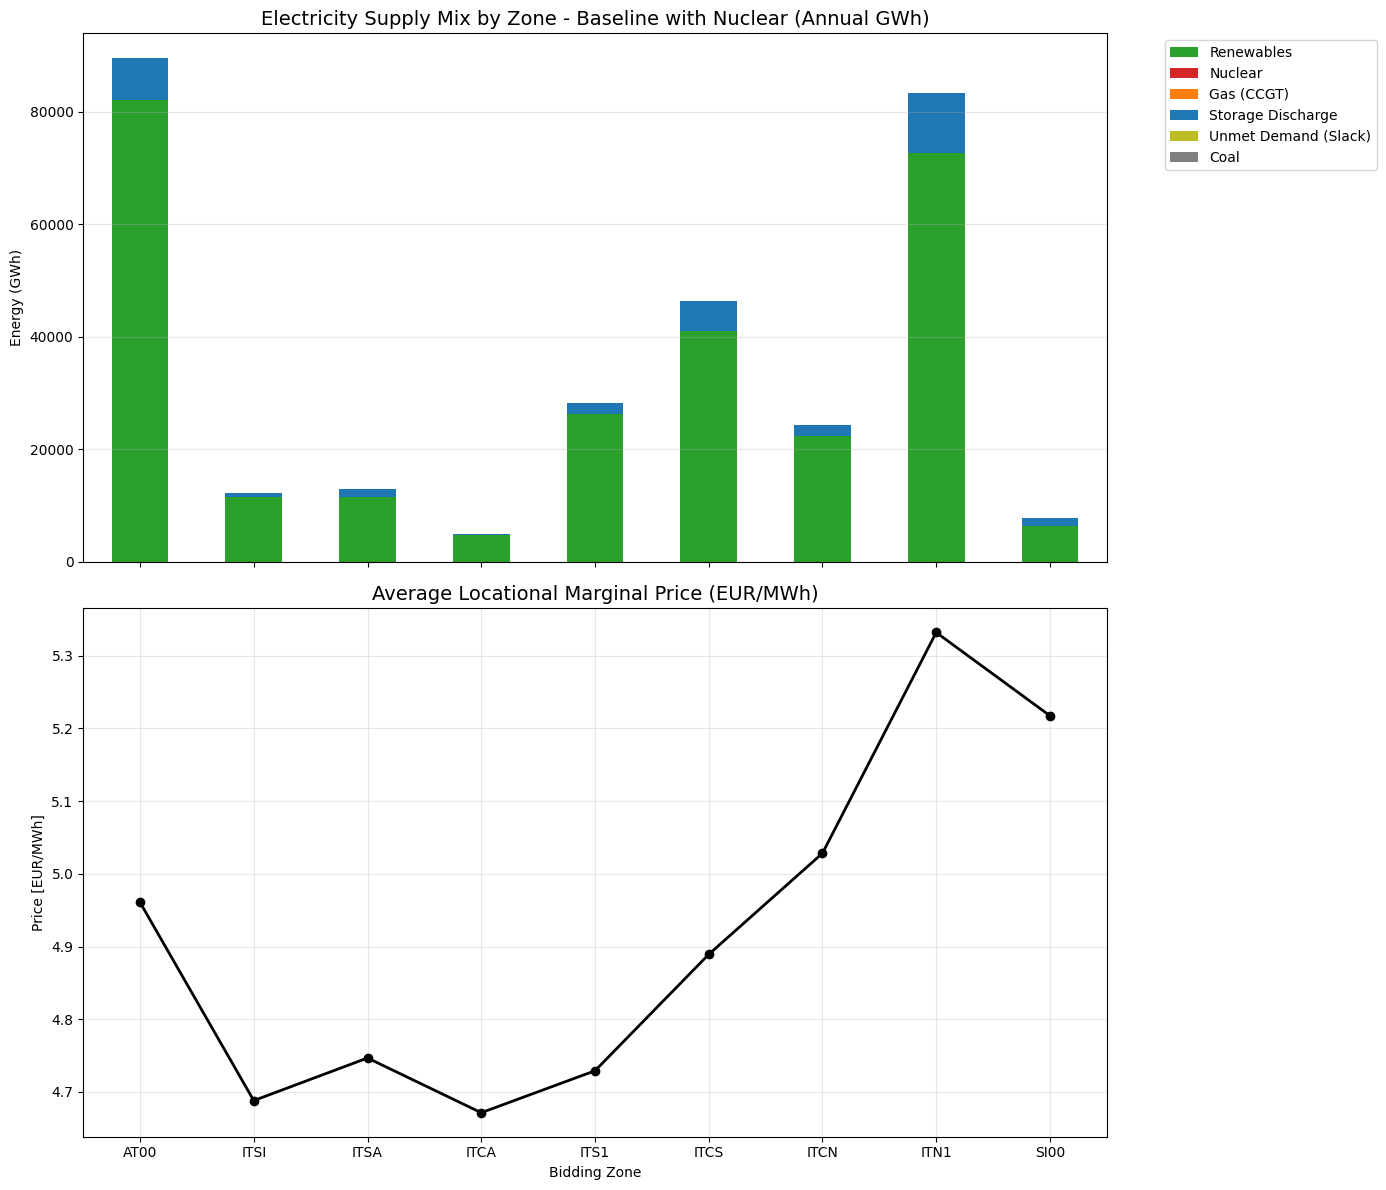

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Summarize Electricity Supply Mix (Annual GWh) for ALL zones in n_elec
supply_summary = {}
all_elec_zones = n_elec.buses[n_elec.buses.index.str.contains('_electricity')].index.str.replace('_electricity', '')

for zone in all_elec_zones:
    zone_supply = {}
    elec_bus = f"{zone}_electricity"

    # Renewables (RES)
    res_gen_name = f"{zone}_RES"
    if res_gen_name in n_elec.generators.index:
        zone_supply['Renewables'] = n_elec.generators_t.p[res_gen_name].sum() / 1e3
    else:
        zone_supply['Renewables'] = 0

    # Nuclear
    nuc_gen_name = f"{zone}_Nuclear"
    if nuc_gen_name in n_elec.generators.index:
        zone_supply['Nuclear'] = n_elec.generators_t.p[nuc_gen_name].sum() / 1e3

    # Gas (CCGT)
    ccgt_name = f"{zone}_CCGT"
    if ccgt_name in n_elec.links.index:
        zone_supply['Gas (CCGT)'] = -n_elec.links_t.p1[ccgt_name].sum() / 1e3

    # Coal
    coal_name = f"{zone}_Coal"
    if coal_name in n_elec.links.index:
        zone_supply['Coal'] = -n_elec.links_t.p1[coal_name].sum() / 1e3

    # Storage Discharging
    storage_units = n_elec.storage_units[n_elec.storage_units.bus == elec_bus].index
    if not storage_units.empty:
        zone_supply['Storage Discharge'] = n_elec.storage_units_t.p_dispatch[storage_units].sum().sum() / 1e3

    # Slack
    slack_name = f"{zone}_elec_slack"
    if slack_name in n_elec.generators.index:
        zone_supply['Unmet Demand (Slack)'] = n_elec.generators_t.p[slack_name].sum() / 1e3

    supply_summary[zone] = zone_supply

# 2. Extract Average Prices
avg_prices = n_elec.buses_t.marginal_price[[f"{z}_electricity" for z in all_elec_zones]].mean()

# 3. Plotting
df_supply_final = pd.DataFrame(supply_summary).T.fillna(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Explicit colors for better visibility
colors = {'Renewables': '#2ca02c', 'Nuclear': '#d62728', 'Gas (CCGT)': '#ff7f0e', 'Coal': '#7f7f7f', 'Storage Discharge': '#1f77b4', 'Unmet Demand (Slack)': '#bcbd22'}
df_supply_final.plot(kind='bar', stacked=True, ax=ax1, color=[colors.get(x, '#333333') for x in df_supply_final.columns])

ax1.set_title("Electricity Supply Mix by Zone - Baseline with Nuclear (Annual GWh)", fontsize=14)
ax1.set_ylabel("Energy (GWh)")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

avg_prices.index = avg_prices.index.str.replace('_electricity', '')
avg_prices.plot(kind='line', marker='o', color='black', ax=ax2, linewidth=2)
ax2.set_title("Average Locational Marginal Price (EUR/MWh)", fontsize=14)
ax2.set_ylabel("Price [EUR/MWh]")
ax2.set_xlabel("Bidding Zone")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Average Electricity Clearing Prices per Zone (Electricity-Only Network):


,Bus,Avg Clearing Price [EUR/MWh]
0,AT00_electricity,4.960782
3,ITCA_electricity,4.671330
6,ITCN_electricity,5.028336
5,ITCS_electricity,4.889178
7,ITN1_electricity,5.332129
4,ITS1_electricity,4.729013
2,ITSA_electricity,4.746607
1,ITSI_electricity,4.688008
8,SI00_electricity,5.217551


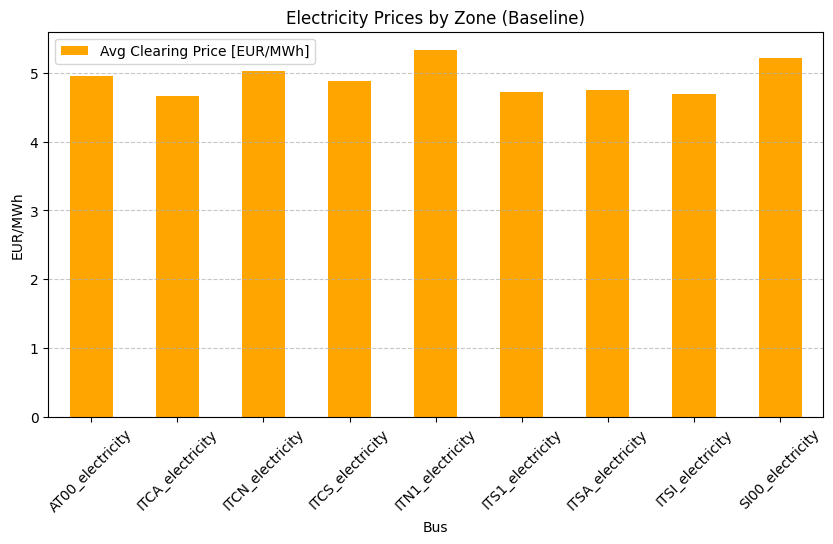

In [75]:
# Extract average marginal prices for electricity buses in the electricity-only network
elec_prices = n_elec.buses_t.marginal_price[[col for col in n_elec.buses_t.marginal_price.columns if 'electricity' in col]].mean()

# Create a cleaner DataFrame for display
elec_price_df = elec_prices.reset_index()
elec_price_df.columns = ['Bus', 'Avg Clearing Price [EUR/MWh]']

# Sort for readability
elec_price_df = elec_price_df.sort_values(by='Bus')

print("Average Electricity Clearing Prices per Zone (Electricity-Only Network):")
display(elec_price_df)

# Simple bar plot for comparison
elec_price_df.set_index('Bus').plot(kind='bar', figsize=(10, 5), color='orange', ylabel='EUR/MWh', title='Electricity Prices by Zone (Baseline)')
import matplotlib.pyplot as plt
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

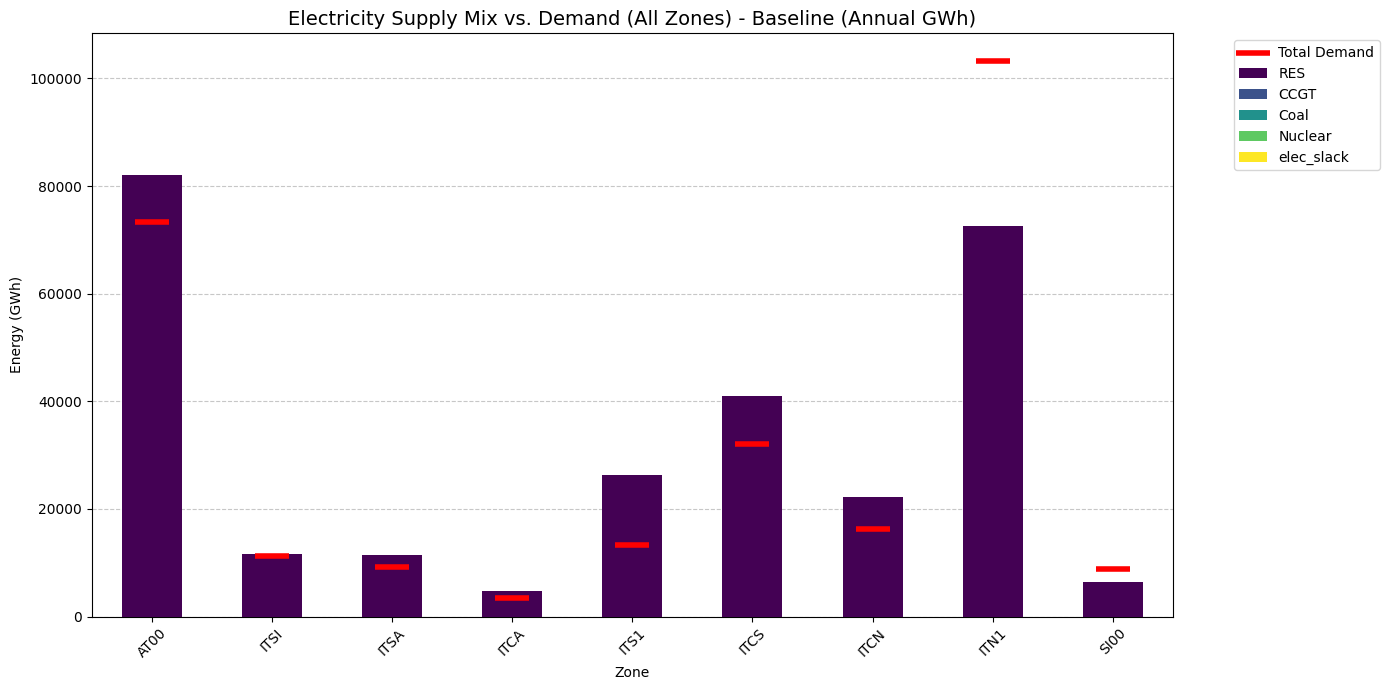

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define supply and demand components for ALL zones
all_zones = n_elec.buses.index[n_elec.buses.index.str.contains('_electricity')].str.replace('_electricity', '')
supply_carriers = ['RES', 'CCGT', 'Coal', 'Nuclear', 'elec_slack']

# 2. Extract Data from the solved network
supply_data = {}
for zone in all_zones:
    zone_supply = {}
    for carrier in supply_carriers:
        val = 0
        if carrier in ['RES', 'Nuclear', 'elec_slack']:
            gen_name = f"{zone}_{carrier}" if carrier != 'elec_slack' else f"{zone}_elec_slack"
            if gen_name in n_elec.generators_t.p.columns:
                val = n_elec.generators_t.p[gen_name].sum()
        elif carrier in ['CCGT', 'Coal']:
            link_name = f"{zone}_{carrier}"
            if link_name in n_elec.links_t.p1.columns:
                val = -n_elec.links_t.p1[link_name].sum()

        zone_supply[carrier] = val / 1e3 # Convert to GWh
    supply_data[zone] = zone_supply

# 3. Extract Demand Data
demand_data = {zone: n_elec.loads_t.p[f'{zone}_demand'].sum() / 1e3 for zone in all_zones}

# 4. Create DataFrame
df_supply_all = pd.DataFrame(supply_data).T
df_demand_all = pd.Series(demand_data, name='Demand')

# 5. Plotting
fig, ax = plt.subplots(figsize=(14, 7))
df_supply_all.plot(kind='bar', stacked=True, ax=ax, zorder=3, colormap='viridis')

# Add demand lines
x_coords = range(len(all_zones))
ax.scatter(x_coords, df_demand_all.values, color='red', label='Total Demand', marker='_', s=600, linewidth=4, zorder=4)

plt.title("Electricity Supply Mix vs. Demand (All Zones) - Baseline (Annual GWh)", fontsize=14)
plt.ylabel("Energy (GWh)")
plt.xlabel("Zone")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
# Find the maximum hourly unserved electricity demand (slack) across all zones
elec_slack_cols = [c for c in n_elec.generators_t.p.columns if 'elec_slack' in c]
max_hourly_slack = n_elec.generators_t.p[elec_slack_cols].max()

print("Maximum Hourly Electricity Slack Usage (MW):")
display(max_hourly_slack[max_hourly_slack > 1e-3])

if max_hourly_slack.max() < 1e-3:
    print("\n✅ Confirmed: There is zero uncovered electricity demand in any hour of the year.")
else:
    print(f"\n☑☑ Analysis: There are still small gaps in supply reaching a peak of {max_hourly_slack.max():.2f} MW.")

Maximum Hourly Electricity Slack Usage (MW):


,0
name,



✅ Confirmed: There is zero uncovered electricity demand in any hour of the year.


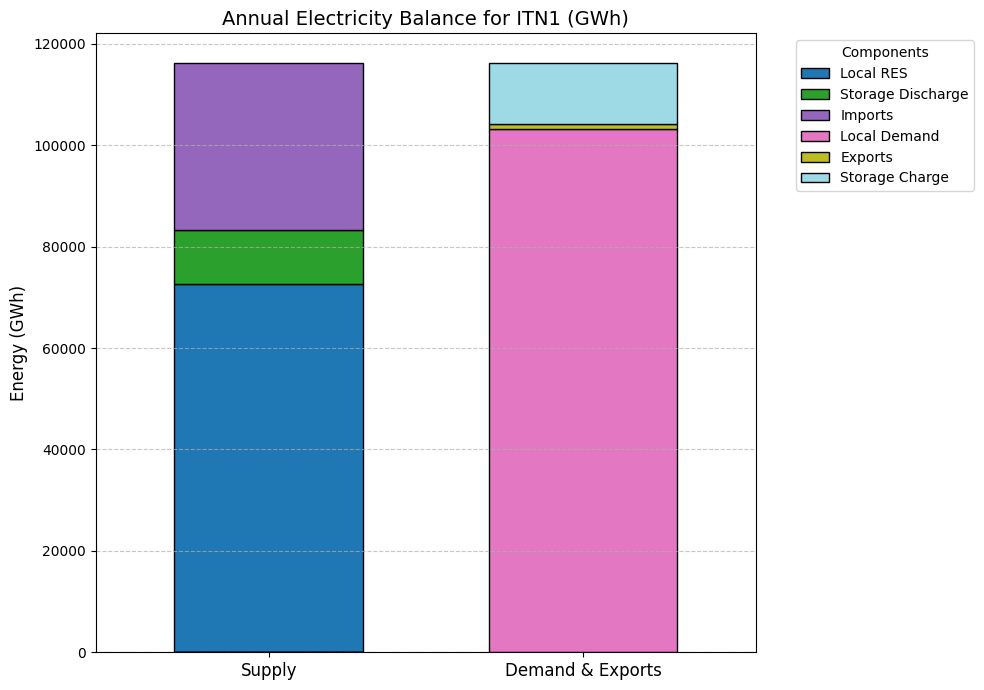

Total Supply: 116257.26 GWh
Total Demand & Exports: 116257.26 GWh


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

zone = 'ITN1'
elec_bus = f'{zone}_electricity'

# 1. Local Demand
demand = n_elec.loads_t.p[f'{zone}_demand'].sum() / 1000

# 2. Local Generation
gen_res = n_elec.generators_t.p[f'{zone}_RES'].sum() / 1000 if f'{zone}_RES' in n_elec.generators.index else 0
gen_ccgt = -n_elec.links_t.p1[f'{zone}_CCGT'].sum() / 1000 if f'{zone}_CCGT' in n_elec.links.index else 0
gen_coal = -n_elec.links_t.p1[f'{zone}_Coal'].sum() / 1000 if f'{zone}_Coal' in n_elec.links.index else 0
gen_nuc = n_elec.generators_t.p[f'{zone}_Nuclear'].sum() / 1000 if f'{zone}_Nuclear' in n_elec.generators.index else 0
slack = n_elec.generators_t.p[f'{zone}_elec_slack'].sum() / 1000 if f'{zone}_elec_slack' in n_elec.generators.index else 0

# 3. Storage
storage_units = n_elec.storage_units[n_elec.storage_units.bus == elec_bus].index
storage_discharge = n_elec.storage_units_t.p_dispatch[storage_units].sum().sum() / 1000 if not storage_units.empty else 0
storage_charge = n_elec.storage_units_t.p_store[storage_units].sum().sum() / 1000 if not storage_units.empty else 0

# 4. Imports and Exports
imports = 0
exports = 0

# Links where ITN1 is bus0 (p0 > 0 means export, p0 < 0 means import)
links_bus0 = n_elec.links[n_elec.links.bus0 == elec_bus].index
for link in links_bus0:
    flow = n_elec.links_t.p0[link]
    imports += flow[flow < 0].sum() * -1 / 1000
    exports += flow[flow > 0].sum() / 1000

# Links where ITN1 is bus1 (p1 > 0 means export, p1 < 0 means import)
links_bus1 = n_elec.links[n_elec.links.bus1 == elec_bus].index
for link in links_bus1:
    flow = n_elec.links_t.p1[link]
    imports += flow[flow < 0].sum() * -1 / 1000
    exports += flow[flow > 0].sum() / 1000

# 5. Prepare Data for Plotting
supply_dict = {
    'Local RES': gen_res,
    'Local CCGT': gen_ccgt,
    'Local Coal': gen_coal,
    'Local Nuclear': gen_nuc,
    'Storage Discharge': storage_discharge,
    'Imports': imports,
    'Slack (Unmet)': slack
}

usage_dict = {
    'Local Demand': demand,
    'Exports': exports,
    'Storage Charge': storage_charge
}

# Filter out zero values for a cleaner legend
supply_dict = {k: v for k, v in supply_dict.items() if v > 0}
usage_dict = {k: v for k, v in usage_dict.items() if v > 0}

df_plot = pd.DataFrame([supply_dict, usage_dict], index=['Supply', 'Demand & Exports']).fillna(0)

# 6. Plotting
fig, ax = plt.subplots(figsize=(10, 7))
df_plot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black', width=0.6)

plt.title(f"Annual Electricity Balance for {zone} (GWh)", fontsize=14)
plt.ylabel("Energy (GWh)", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.legend(title="Components", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Total Supply: {sum(supply_dict.values()):.2f} GWh")
print(f"Total Demand & Exports: {sum(usage_dict.values()):.2f} GWh")


Detailed Import Breakdown for ITN1 (GWh):
  - Imported from ITCN: 14,849.92 GWh
  - Imported from ITCS: 12,810.94 GWh
  - Imported from AT00: 4,061.68 GWh
  - Imported from SI00: 1,157.87 GWh


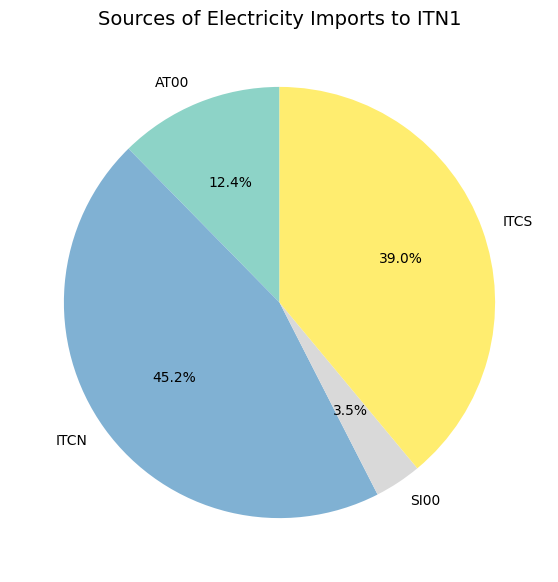

In [79]:
import_breakdown = {}

# Links where ITN1 is bus0 (p0 < 0 means import from bus1)
links_bus0 = n_elec.links[n_elec.links.bus0 == elec_bus].index
for link in links_bus0:
    neighbor = n_elec.links.at[link, 'bus1'].replace('_electricity', '')
    flow = n_elec.links_t.p0[link]
    imported_gwh = flow[flow < 0].sum() * -1 / 1000
    if imported_gwh > 0:
        import_breakdown[neighbor] = import_breakdown.get(neighbor, 0) + imported_gwh

# Links where ITN1 is bus1 (p1 < 0 means import from bus0)
links_bus1 = n_elec.links[n_elec.links.bus1 == elec_bus].index
for link in links_bus1:
    neighbor = n_elec.links.at[link, 'bus0'].replace('_electricity', '')
    flow = n_elec.links_t.p1[link]
    imported_gwh = flow[flow < 0].sum() * -1 / 1000
    if imported_gwh > 0:
        import_breakdown[neighbor] = import_breakdown.get(neighbor, 0) + imported_gwh

print(f"Detailed Import Breakdown for {zone} (GWh):")
for neighbor, gwh in sorted(import_breakdown.items(), key=lambda x: x[1], reverse=True):
    print(f"  - Imported from {neighbor}: {gwh:,.2f} GWh")

# Plotting the breakdown
if import_breakdown:
    plt.figure(figsize=(7, 7))
    pd.Series(import_breakdown).plot(kind='pie', autopct='%1.1f%%', colormap='Set3', startangle=90)
    plt.title(f"Sources of Electricity Imports to {zone}", fontsize=14)
    plt.ylabel("")
    plt.show()


Link: Elec_Link_AT00_ITN1 | Capacity: 875.0 MW | Congested: 71.70%
Link: Elec_Link_SI00_ITN1 | Capacity: 1153.0 MW | Congested: 19.93%
Link: Elec_Link_ITCN_ITN1 | Capacity: 4500.0 MW | Congested: 31.45%
Link: Elec_Link_ITCS_ITCN | Capacity: 5350.0 MW | Congested: 15.86%
Link: Elec_Link_ITCS_ITN1 | Capacity: 2000.0 MW | Congested: 96.47%


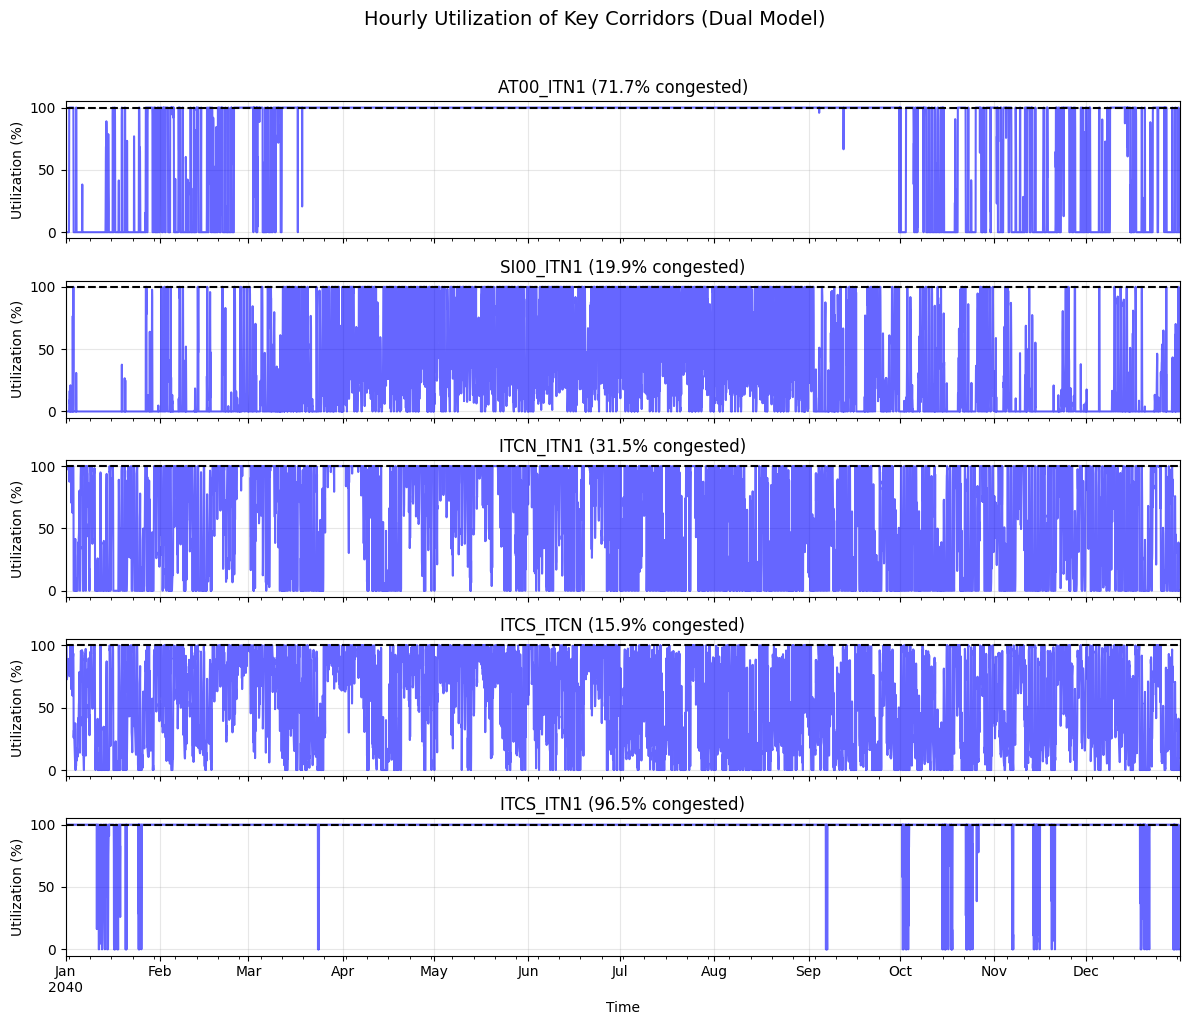

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the corridors of interest (with the missing comma fixed)
corridors = [
    'Elec_Link_AT00_ITN1', # Import to ITN1 from AT00
    'Elec_Link_SI00_ITN1', # Import to ITN1 from SI00
    'Elec_Link_ITCN_ITN1', # Import to ITN1 from ITCN
    'Elec_Link_ITCS_ITCN', # Import to ITCN from ITCS
    'Elec_Link_ITCS_ITN1'  # Import to ITCN from ITCS
]

# Vertical layout: len(corridors) rows, 1 column
fig, axes = plt.subplots(len(corridors), 1, figsize=(12, 10), sharex=True)

for i, link_name in enumerate(corridors):
    ax = axes[i]
    if link_name in n_dual.links.index:
        capacity = n_dual.links.at[link_name, 'p_nom']
        flow = n_dual.links_t.p0[link_name].abs()

        # Calculate utilization percentage
        utilization = (flow / capacity) * 100

        # Count congested hours
        congested_hours = (utilization > 99.9).sum()
        total_hours = len(n_dual.snapshots)
        percent_time_congested = (congested_hours / total_hours) * 100

        # Plotting
        utilization.plot(ax=ax, color='blue', alpha=0.6)
        ax.axhline(100, color='black', linestyle='--')
        ax.set_title(f"{link_name.replace('Elec_Link_', '')} ({percent_time_congested:.1f}% congested)", fontsize=12)

        # Only label the x-axis on the bottom plot
        if i == len(corridors) - 1:
            ax.set_xlabel("Time")

        ax.set_ylabel("Utilization (%)")
        ax.grid(True, alpha=0.3)

        # Print text summary
        print(f"Link: {link_name} | Capacity: {capacity} MW | Congested: {percent_time_congested:.2f}%")
    else:
        ax.text(0.5, 0.5, f"{link_name}\nNot Found", ha='center', va='center', fontsize=12, color='grey')
        ax.set_axis_off()
        print(f"Link {link_name} not found in the network.")

plt.suptitle("Hourly Utilization of Key Corridors (Dual Model)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Comparison of Annual Electricity Demand (TWh):


,Demand_Dual_Model (TWh),Demand_Elec_Only (TWh)
Zone,,
AT00,73.27,73.27
ITSI,11.30,11.30
ITSA,9.17,9.17
ITCA,3.49,3.49
ITS1,13.29,13.29
ITCS,32.01,32.01
ITCN,16.23,16.23
ITN1,103.22,103.22
SI00,8.75,8.75


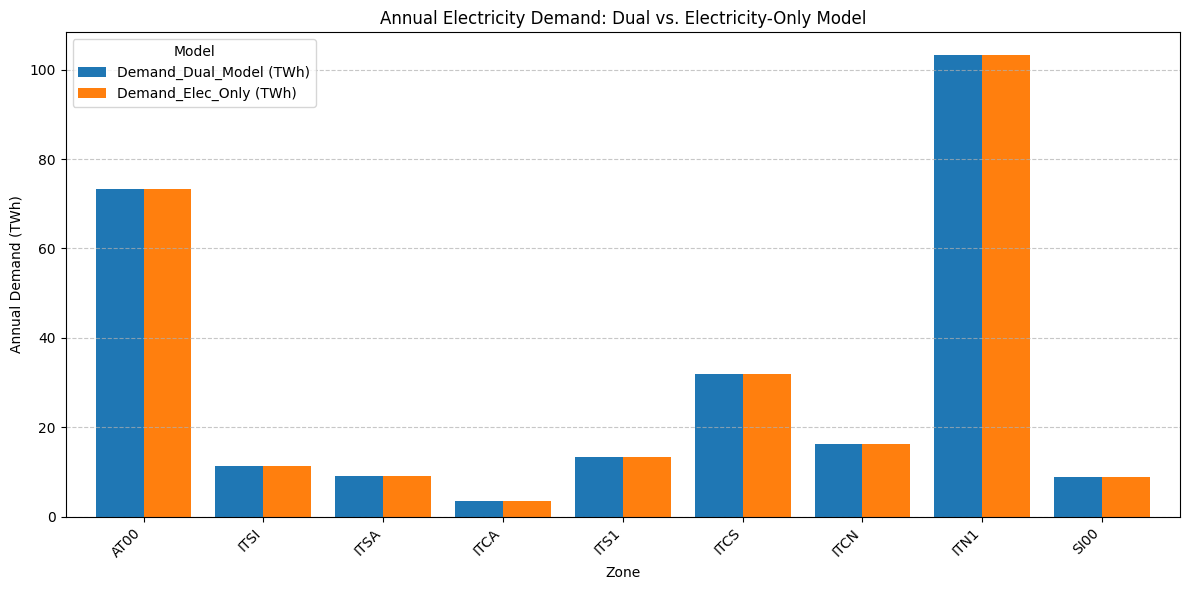

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for comparing electricity demand
demand_comparison_data = []

for zone in zones:
    # Get electricity demand from the Dual Model (n_dual)
    elec_demand_n_col = f'{zone}_elec_demand'
    demand_n_twh = 0
    if elec_demand_n_col in n_dual.loads_t.p.columns:
        demand_n_twh = n_dual.loads_t.p[elec_demand_n_col].sum() / 1e6 # Convert to TWh

    # Get electricity demand from the Electricity-Only Model (n_elec)
    elec_demand_nelec_col = f'{zone}_demand'
    demand_nelec_twh = 0
    if elec_demand_nelec_col in n_elec.loads_t.p.columns:
        demand_nelec_twh = n_elec.loads_t.p[elec_demand_nelec_col].sum() / 1e6 # Convert to TWh

    demand_comparison_data.append({
        'Zone': zone,
        'Demand_Dual_Model (TWh)': demand_n_twh,
        'Demand_Elec_Only (TWh)': demand_nelec_twh
    })

df_demand_comparison = pd.DataFrame(demand_comparison_data).set_index('Zone')

print("Comparison of Annual Electricity Demand (TWh):")
display(df_demand_comparison.round(2))

# Plotting demand comparison
plt.figure(figsize=(12, 6))
df_demand_comparison.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Annual Electricity Demand: Dual vs. Electricity-Only Model')
plt.ylabel('Annual Demand (TWh)')
plt.xlabel('Zone')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Non-flexible RES Profile Comparison for AT00:


,Original (model_data),Dual Model (n_dual),Electricity-Only Model (n_elec)
2040-01-01 00:00:00,4052.803001,4052.803001,4052.803001
2040-01-01 01:00:00,4100.621813,4100.621813,4100.621813
2040-01-01 02:00:00,3982.951088,3982.951088,3982.951088
2040-01-01 03:00:00,3932.338721,3932.338721,3932.338721
2040-01-01 04:00:00,3986.517445,3986.517445,3986.517445



Original and Dual Model RES profiles are identical: True
Original and Electricity-Only Model RES profiles are identical: True


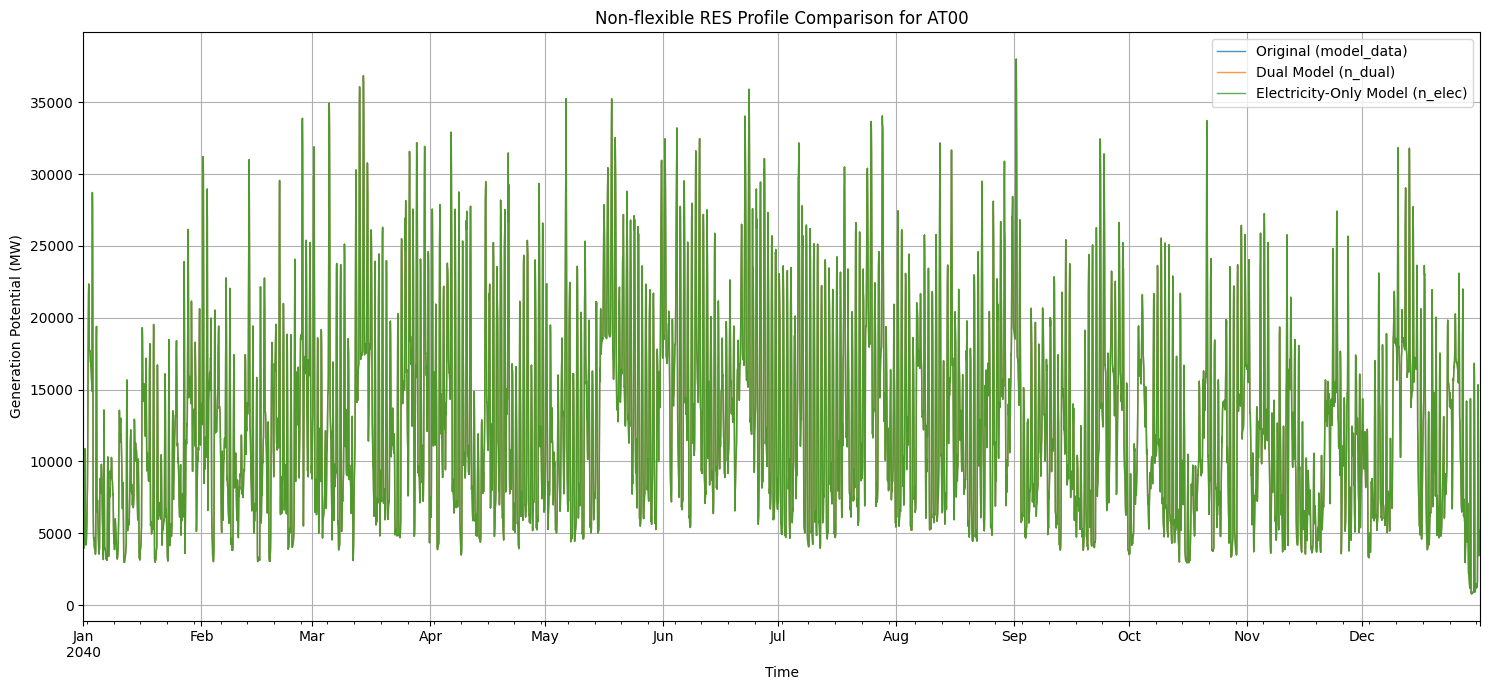

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# Choose a sample zone for comparison
sample_zone = 'AT00'

# 1. Get the original Nonflex_Total_RES profile from model_data
original_res_profile = model_data[sample_zone]['Nonflex_Total_RES']

# 2. Get the Nonflex_Total_RES profile from the dual model (n_dual)
# In n_dual, the RES is either split into SRES and DRES or added directly as RES_plant
res_name = f'{sample_zone}_RES_plant'
sres_name = f'{sample_zone}_SRES_plant'
dres_name = f'{sample_zone}_DRES_plant'

dual_model_res_profile = pd.Series(0.0, index=n_dual.snapshots)
if res_name in n_dual.generators.index:
    dual_model_res_profile += n_dual.generators_t.p_max_pu[res_name] * n_dual.generators.at[res_name, 'p_nom']
if sres_name in n_dual.generators.index:
    dual_model_res_profile += n_dual.generators_t.p_max_pu[sres_name] * n_dual.generators.at[sres_name, 'p_nom']
if dres_name in n_dual.generators.index:
    dual_model_res_profile += n_dual.generators_t.p_max_pu[dres_name] * n_dual.generators.at[dres_name, 'p_nom']

# 3. Get the Nonflex_Total_RES profile from the electricity-only model (n_elec)
elec_res_name = f'{sample_zone}_RES'
elec_only_res_profile = n_elec.generators_t.p_max_pu[elec_res_name] * n_elec.generators.at[elec_res_name, 'p_nom']

# Create a DataFrame for comparison
res_profile_comparison = pd.DataFrame({
    'Original (model_data)': original_res_profile,
    'Dual Model (n_dual)': dual_model_res_profile,
    'Electricity-Only Model (n_elec)': elec_only_res_profile
})

# Display the head of the comparison DataFrame
print(f"Non-flexible RES Profile Comparison for {sample_zone}:")
display(res_profile_comparison.head())

# Check if the profiles are identical (or very close due to floating point)
profiles_identical_dual = original_res_profile.round(2).equals(dual_model_res_profile.round(2))
profiles_identical_elec = original_res_profile.round(2).equals(elec_only_res_profile.round(2))

print(f"\nOriginal and Dual Model RES profiles are identical: {profiles_identical_dual}")
print(f"Original and Electricity-Only Model RES profiles are identical: {profiles_identical_elec}")

# Plot the profiles to visually confirm
plt.figure(figsize=(15, 7))
res_profile_comparison.plot(ax=plt.gca(), linewidth=1, alpha=0.8)
plt.title(f'Non-flexible RES Profile Comparison for {sample_zone}')
plt.ylabel('Generation Potential (MW)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Global Model Comparison: Dual vs. Electricity-Only
We compare the overall performance and outputs of both models to ensure the integration of hydrogen/synthetic fuel buses (even when demand is 0) hasn't shifted the electricity equilibrium.

--- Pipeline Congestion Analysis ---


,Congested Hours (% of Year)
name,
H2_Pipe_AT00_ITN1,0.0
H2_Pipe_ITN1_AT00,0.0
H2_Pipe_ITSI_ITCA,0.0
H2_Pipe_ITCA_ITSI,0.0
H2_Pipe_ITCA_ITS1,0.0
H2_Pipe_ITS1_ITCA,0.0
H2_Pipe_ITS1_ITCS,0.0
H2_Pipe_ITCS_ITS1,0.0
H2_Pipe_ITCS_ITCN,0.0


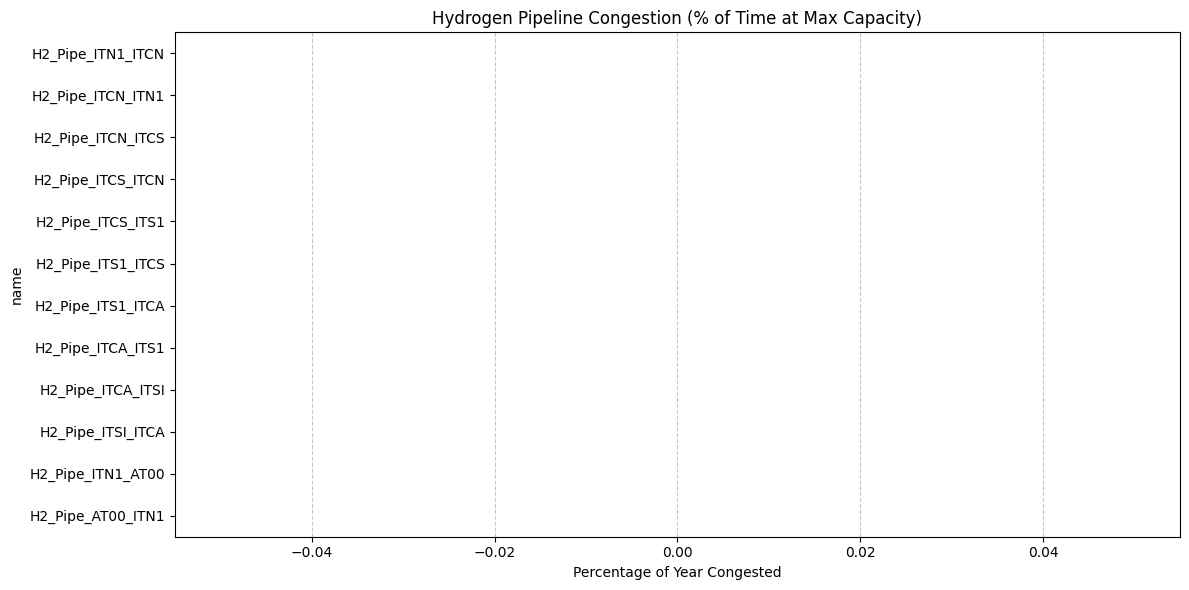


--- Net Annual Pipeline Flows (GWh) ---


,Net Flow (GWh)
name,
H2_Pipe_AT00_ITN1,0.000000
H2_Pipe_ITN1_AT00,19267.051444
H2_Pipe_ITSI_ITCA,85259.899957
H2_Pipe_ITCA_ITSI,0.000000
H2_Pipe_ITCA_ITS1,86963.645547
H2_Pipe_ITS1_ITCA,0.000000
H2_Pipe_ITS1_ITCS,96085.271962
H2_Pipe_ITCS_ITS1,0.000000
H2_Pipe_ITCS_ITCN,97679.588898


In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify all Hydrogen Pipeline links
h2_pipes = n_dual.links[n_dual.links.index.str.contains('H2_Pipe')].index

if not h2_pipes.empty:
    # Calculate hourly utilization (%)
    # p0 is the flow. We compare absolute flow to the nominal capacity.
    pipe_caps = n_dual.links.loc[h2_pipes, 'p_nom']
    utilization = (n_dual.links_t.p0[h2_pipes].abs().div(pipe_caps, axis=1) * 100)

    # 2. Identify Congested Hours (Utilization > 99%)
    congestion_stats = (utilization > 99.0).mean() * 100
    congestion_stats = congestion_stats.rename("Congested Hours (% of Year)")

    print("--- Pipeline Congestion Analysis ---")
    display(congestion_stats.to_frame().round(2))

    # 3. Visualize the Bottlenecks
    plt.figure(figsize=(12, 6))
    congestion_stats.sort_values().plot(kind='barh', color='darkred')
    plt.title("Hydrogen Pipeline Congestion (% of Time at Max Capacity)")
    plt.xlabel("Percentage of Year Congested")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 4. Check Net Annual Flow Direction
    # Positive means flow from bus0 to bus1
    net_flows = n_dual.links_t.p0[h2_pipes].sum() / 1e3 # GWh
    print("\n--- Net Annual Pipeline Flows (GWh) ---")
    display(net_flows.to_frame('Net Flow (GWh)'))
else:
    print("No hydrogen pipeline links found to analyze.")

In [84]:
import pandas as pd

# 1. Compare Objective Values
obj_dual = n_dual.objective
obj_elec = n_elec.objective
print(f"Objective n_dual: {obj_dual:,.2f} EUR")
print(f"Objective n_elec: {obj_elec:,.2f} EUR")
print(f"Difference: {obj_dual - obj_elec:,.2f} EUR")

# 2. Compare Total Generation per Carrier (Aggregated across all zones)
def get_total_gen(network, model_type):
    # Generators
    gen = network.generators_t.p.sum().groupby(network.generators.carrier).sum()
    # Links (CCGT, Coal, and SRES/DRES to grid)
    # p1 is negative for flow out of the link into the bus
    link_gen = (network.links_t.p1 * -1).sum().groupby(network.links.carrier).sum()
    combined = pd.concat([gen, link_gen]).groupby(level=0).sum() / 1e6 # TWh
    return combined.rename(model_type)

gen_dual_total = get_total_gen(n_dual, 'Dual Model (TWh)')
gen_elec_total = get_total_gen(n_elec, 'Elec-Only (TWh)')

comparison_gen = pd.concat([gen_dual_total, gen_elec_total], axis=1).fillna(0)
print("\nTotal Annual Generation Comparison (TWh):")
display(comparison_gen.round(4))

# 3. Compare Average Prices per Zone
prices_dual = n_dual.buses_t.marginal_price[[c for c in n_dual.buses_t.marginal_price.columns if 'electricity_market' in c]].mean()
prices_dual.index = prices_dual.index.str.replace('_electricity_market', '')

prices_elec = n_elec.buses_t.marginal_price[[c for c in n_elec.buses_t.marginal_price.columns if 'electricity' in c]].mean()
prices_elec.index = prices_elec.index.str.replace('_electricity', '')

price_diff = pd.concat([prices_dual.rename('Dual Price'), prices_elec.rename('Elec-Only Price')], axis=1)
price_diff['Delta'] = price_diff['Dual Price'] - price_diff['Elec-Only Price']

print("\nPrice Comparison per Zone (EUR/MWh):")
display(price_diff.round(2))

Objective n_dual: 21,731,550,343.78 EUR
Objective n_elec: 1,280,678,615.80 EUR
Difference: 20,450,871,727.98 EUR

Total Annual Generation Comparison (TWh):


,Dual Model (TWh),Elec-Only (TWh)
carrier,,
,23.4018,0.0000
AC,689.6237,343.4426
H2,573.9850,0.0000
coal,9.3607,0.0000
natural_gas,92.6314,0.0000
nuclear,46.9768,0.0000
slack,0.0000,0.0000



Price Comparison per Zone (EUR/MWh):


,Dual Price,Elec-Only Price,Delta
name,,,
AT00,55.94,4.96,50.98
ITSI,47.41,4.69,42.73
ITSA,50.19,4.75,45.44
ITCA,52.31,4.67,47.63
ITS1,55.06,4.73,50.33
ITCS,63.53,4.89,58.64
ITCN,66.94,5.03,61.92
ITN1,71.00,5.33,65.67
SI00,69.03,5.22,63.82


In [85]:
import pandas as pd

# 1. Compare Nominal Capacities of Storage Units
storage_cap_dual = n_dual.storage_units.groupby(['bus', 'carrier']).p_nom.sum()
storage_cap_elec = n_elec.storage_units.groupby(['bus', 'carrier']).p_nom.sum()

# Rename indices for comparison (removing model-specific bus suffixes)
storage_cap_dual.index = storage_cap_dual.index.map(lambda x: (x[0].replace('_electricity_market', ''), x[1]))
storage_cap_elec.index = storage_cap_elec.index.map(lambda x: (x[0].replace('_electricity', ''), x[1]))

cap_comparison = pd.concat([storage_cap_dual.rename('Dual (MW)'), storage_cap_elec.rename('Elec-Only (MW)')], axis=1).fillna(0)

# 2. Compare Annual Dispatch (Generation from Storage)
disp_dual = n_dual.storage_units_t.p_dispatch.sum().groupby([n_dual.storage_units.bus, n_dual.storage_units.carrier]).sum() / 1e3 # GWh
disp_elec = n_elec.storage_units_t.p_dispatch.sum().groupby([n_elec.storage_units.bus, n_elec.storage_units.carrier]).sum() / 1e3 # GWh

disp_dual.index = disp_dual.index.map(lambda x: (x[0].replace('_electricity_market', ''), x[1]))
disp_elec.index = disp_elec.index.map(lambda x: (x[0].replace('_electricity', ''), x[1]))

disp_comparison = pd.concat([disp_dual.rename('Dual Dispatch (GWh)'), disp_elec.rename('Elec-Only Dispatch (GWh)')], axis=1).fillna(0)

print("--- Storage Capacity Comparison ---")
display(cap_comparison)

print("\n--- Annual Storage Dispatch Comparison ---")
display(disp_comparison.round(2))

# 3. Summary of differences
diff_cap = (cap_comparison['Dual (MW)'] - cap_comparison['Elec-Only (MW)']).abs().sum()
diff_disp = (disp_comparison['Dual Dispatch (GWh)'] - disp_comparison['Elec-Only Dispatch (GWh)']).abs().sum()

if diff_cap < 1e-3 and diff_disp < 1e-3:
    print("\n✅ The electricity storage assets and their behaviors are identical in both models.")
else:
    print(f"\n⚠️ Differences detected! Capital Delta: {diff_cap:.2f} MW, Dispatch Delta: {diff_disp:.2f} GWh.")

--- Storage Capacity Comparison ---


Dual (MW)  Elec-Only (MW)
bus           carrier                              
AT00          battery    238.695496      238.695496
              hydro    12468.936000    12468.936000
AT00_h2_zone1 H2         359.593600        0.000000
ITCA          battery   1863.000000     1863.000000
              hydro      701.284000      701.284000
ITCA_h2_zone1 H2         210.296571        0.000000
ITCA_h2_zone2 H2         286.430607        0.000000
ITCN          battery   1540.000000     1540.000000
              hydro      389.270000      389.270000
ITCN_h2_zone1 H2         210.296571        0.000000
ITCN_h2_zone2 H2         286.430607        0.000000
ITCS          battery   4702.100000     4702.100000
              hydro     2750.457000     2750.457000
ITCS_h2_zone1 H2         210.296571        0.000000
ITCS_h2_zone2 H2         286.430607        0.000000
ITN1          battery   5296.000000     5296.000000
              hydro    11550.032000    11550.032000
ITN1_h2_zone1 H2         210.296571        0.000000
ITN1_h2_zone2 H2         286.430607        0.000000
ITS1          battery   6125.500000     6125.500000
              hydro      178.270000      178.270000
ITS1_h2_zone1 H2         210.296571        0.000000
ITS1_h2_zone2 H2         286.430607        0.000000
ITSA          battery   2917.000000     2917.000000
              hydro      393.397500      393.397500
ITSA_h2_zone1 H2         210.296571        0.000000
ITSA_h2_zone2 H2         286.430607        0.000000
ITSI          battery   4467.000000     4467.000000
              hydro      622.340000      622.340000
ITSI_h2_zone1 H2         210.296571        0.000000
ITSI_h2_zone2 H2         286.430607        0.000000
SI00          battery   1206.800000     1206.800000
              hydro     1709.700000     1709.700000
SI00_h2_zone1 H2          65.252140        0.000000


--- Annual Storage Dispatch Comparison ---


Dual Dispatch (GWh)  Elec-Only Dispatch (GWh)
bus           carrier                                               
AT00          battery                88.16                     93.34
              hydro                7485.39                   7249.52
AT00_h2_zone1 H2                    991.73                      0.00
ITCA          battery              2112.27                    144.23
              hydro                 699.07                     21.99
ITCA_h2_zone1 H2                      0.00                      0.00
ITCA_h2_zone2 H2                      0.00                      0.00
ITCN          battery              1196.08                   1944.16
              hydro                 147.91                    147.16
ITCN_h2_zone1 H2                      0.00                      0.00
ITCN_h2_zone2 H2                      0.00                      0.00
ITCS          battery              4361.97                   4916.24
              hydro                 542.73                    413.77
ITCS_h2_zone1 H2                      0.00                      0.00
ITCS_h2_zone2 H2                      0.00                      0.00
ITN1          battery              1774.51                   5914.57
              hydro                1770.00                   4857.39
ITN1_h2_zone1 H2                      0.00                      0.00
ITN1_h2_zone2 H2                      0.00                      0.00
ITS1          battery              6475.96                   1984.37
              hydro                 195.58                     15.81
ITS1_h2_zone1 H2                      0.00                      0.00
ITS1_h2_zone2 H2                      0.00                      0.00
ITSA          battery              3425.06                   1391.62
              hydro                 410.31                      6.49
ITSA_h2_zone1 H2                      0.00                      0.00
ITSA_h2_zone2 H2                      0.00                      0.00
ITSI          battery              4620.60                    734.14
              hydro                 213.25                      0.00
ITSI_h2_zone1 H2                      0.00                      0.00
ITSI_h2_zone2 H2                      0.00                      0.00
SI00          battery               462.47                    615.17
              hydro                 319.17                    786.03
SI00_h2_zone1 H2                    197.21                      0.00


⚠️ Differences detected! Capital Delta: 3901.94 MW, Dispatch Delta: 24562.51 GWh.


### Economic & Energy Consistency Check
Since the objective values are identical to the cent, we verify if the total system load and marginal costs are also identical.

In [86]:
# 1. Total System Energy Balance (TWh)
dual_total_load = n_dual.loads_t.p.sum().sum() / 1e6
elec_total_load = n_elec.loads_t.p.sum().sum() / 1e6

# 2. Check for any non-zero Hydrogen production costs
h2_cost_dual = (n_dual.links_t.p0[[c for c in n_dual.links.index if "Electrolyser" in c]] * n_dual.links.marginal_cost).sum().sum()

print(f"Total Electricity Load (Dual): {dual_total_load:.4f} TWh")
print(f"Total Electricity Load (Elec-Only): {elec_total_load:.4f} TWh")
print(f"Difference in Load: {dual_total_load - elec_total_load:.4f} TWh")
print(f"Hydrogen Production Marginal Cost: {h2_cost_dual:.2f} EUR")

# 3. Compare System-wide Average Price
system_price_dual = n_dual.buses_t.marginal_price[[c for c in n_dual.buses_t.marginal_price.columns if 'electricity_market' in c]].mean().mean()
system_price_elec = n_elec.buses_t.marginal_price[[c for c in n_elec.buses_t.marginal_price.columns if 'electricity' in c]].mean().mean()

print(f"\nSystem Avg Price (Dual): {system_price_dual:.4f} EUR/MWh")
print(f"System Avg Price (Elec-Only): {system_price_elec:.4f} EUR/MWh")

Total Electricity Load (Dual): 425.8235 TWh
Total Electricity Load (Elec-Only): 270.7230 TWh
Difference in Load: 155.1005 TWh
Hydrogen Production Marginal Cost: 0.00 EUR

System Avg Price (Dual): 59.0467 EUR/MWh
System Avg Price (Elec-Only): 4.9181 EUR/MWh


In [87]:
import pandas as pd

def get_cost_breakdown(network, model_name):
    # 1. Operational Costs from Generators (Marginal Cost * Generation)
    gen_costs = (network.generators_t.p * network.generators.marginal_cost).sum().sum()

    # 2. Operational Costs from Links (Marginal Cost * Flow at bus0)
    link_costs = (network.links_t.p0 * network.links.marginal_cost).sum().sum()

    # 3. Storage Unit Marginal Costs (if any)
    storage_costs = (network.storage_units_t.p_dispatch * network.storage_units.marginal_cost).sum().sum()

    total_calc = gen_costs + link_costs + storage_costs

    return {
        "Model": model_name,
        "Generator OpEx [EUR]": gen_costs,
        "Link OpEx (Fuel/Variable) [EUR]": link_costs,
        "Storage OpEx [EUR]": storage_costs,
        "Total Calculated Cost [EUR]": total_calc,
        "Objective Value [EUR]": network.objective
    }

# Calculate for both models
costs_dual = get_cost_breakdown(n_dual, "Dual Model")
costs_elec = get_cost_breakdown(n_elec, "Electricity-Only")

cost_df = pd.DataFrame([costs_dual, costs_elec]).set_index("Model")

print("--- Detailed Optimization Cost Breakdown ---")
display(cost_df.style.format("{:,.2f}"))

# Breakdown per Carrier for the Dual Model
print("\n--- Marginal Costs per Carrier (Dual Model) ---")
gen_carrier_costs = (n_dual.generators_t.p * n_dual.generators.marginal_cost).sum().groupby(n_dual.generators.carrier).sum()
link_carrier_costs = (n_dual.links_t.p0 * n_dual.links.marginal_cost).sum().groupby(n_dual.links.carrier).sum()
carrier_breakdown = pd.concat([gen_carrier_costs, link_carrier_costs]).groupby(level=0).sum()
display(carrier_breakdown.map(lambda x: f"{x:,.2f} EUR"))

--- Detailed Optimization Cost Breakdown ---


,Generator OpEx [EUR],Link OpEx (Fuel/Variable) [EUR],Storage OpEx [EUR],Total Calculated Cost [EUR],Objective Value [EUR]
Model,,,,,
Dual Model,"21,667,613,550.28","63,936,793.49",0.00,"21,731,550,343.77","21,731,550,343.78"
Electricity-Only,"1,280,678,615.80",0.00,0.00,"1,280,678,615.80","1,280,678,615.80"



--- Marginal Costs per Carrier (Dual Model) ---


,0
carrier,
,"585,044,847.57 EUR"
AC,"1,310,570,435.35 EUR"
H2,"16,836,855,240.71 EUR"
coal,0.00 EUR
natural_gas,"2,435,357,836.13 EUR"
nuclear,"563,721,984.00 EUR"
slack,0.00 EUR
